---
title: "Larkins: the authors' own worked example redone, and the average-pressure shortcut under it priced"
description: "Larkins, White and Jeffrey print Table 3 measured and Table 4 calculated for the same eight runs, so the whole chain - Ergun with their own constants, the Lockhart-Martinelli variable, the two-phase parameter - can be redone cell by cell instead of admired. Seven of the eight rows close to 0.639 % or better; run 5 does not, and its pressure drop and its two-phase parameter cannot both be right. The air viscosity they used is printed nowhere and is recovered from their own two tables: linear in temperature to 0.0259 % over seven rows, and 0.819 % from Table 2's own printed value at 80 F, which was not used to find it - 0.672 % once the systematic offset measured on the liquid rows is taken out. Their claim that the arithmetic mean of the terminal pressures gives the correct average friction loss is exact - proved, then measured at 1.16e-13 - for one phase in horizontal flow, and becomes a 1 % error at 5.6012 ft of bed once the two-phase correlation is in the loop. That length is the WORST of Table 3's two-phase rows and is reported as one: the same root-find over the other five gives up to 466.9537 ft, and only one of the six is inside the paper's own 7-ft column."
categories: [sec:G, struct:S3, tier:T0, data:tier2, phase:gas-liquid-solid]
date: 2026-08-14
---

# Larkins: the authors' own worked example redone, and the average-pressure shortcut under it priced

**Catalog ID:** `G1.1` · **Structures:** `S3` (1-D steady BVP) · **Tier:** T0


In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

## Background

Gas and liquid running **down** a packed bed together lose more pressure than
either would alone, and part of the void is occupied by liquid. In 1961
R. P. Larkins, R. R. White and D. W. Jeffrey measured both, over eight fluid
systems and four packings, and correlated them the way Lockhart and Martinelli
had correlated two-phase flow in open pipes: against a single variable built
from the friction losses each phase would suffer **flowing alone in the same
bed**.

What makes this paper worth a page is not the correlation. It is that the
paper prints **a worked example**. Table 3 gives eight runs of measured data;
Table 4 gives, run by run, the authors' own arithmetic on those same eight
rows - two Reynolds numbers, three friction losses, the liquid saturation, the
independent variable $\chi$ and the two-phase parameter. Every constant that
turns one table into the other is printed somewhere in the nine pages. So the
strongest validation the builder brief allows short of held-out data is
available here: **reproduce the authors' arithmetic step by step and see where
it closes and where it does not.**

### What this page does, and in what order

1. **Redo Table 4 from Table 3.** Seven of the eight rows close on every
   column. Run 5 does not, and the page shows why, without repairing it.
2. **Recover a constant the paper never prints.** The air viscosity used in
   Table 4 is not in Table 2 except at one temperature; it is determined, row
   by row, by Table 3 and Table 4 together.
3. **Test Eqs. (22) and (23) against Table 4 - and say plainly that this is a
   goodness of fit, not a test**, with a null baseline printed beside every
   agreement number.
4. **Solve a column with pymrm** and price the shortcut the paper's own design
   procedure rests on: that densities may be evaluated at the arithmetic mean
   of the terminal pressures of a section.

### What is out of scope, and why

The paper carries nine figures. Figures 2-9 are correlation plots whose curves
are the printed equations, and the individual data points that fall around them
are **not tabulated anywhere**. Digitising them is out of scope for this page:
the builder brief ranks a worked example with printed intermediates *above* a
digitised figure and says that when (1)-(3) exist, do not digitise at all. They
do exist here, so nothing on this page is traced off a curve. That means the
page can say nothing about the 600+ points behind Figure 7, about the foaming
deviations of Figure 8, or about the comparison with Lockhart-Martinelli in
Figure 9 beyond what the prose states in words.

The paper's own supporting document - "the complete tabulation of properties,
data and results", reference 4, Larkins's 1959 Michigan PhD thesis, offered on
microfilm - is **not on disk and was not read**. Where the paper defers to it
(and it does so exactly once for a result this page tests) that is said.


## The published model

Everything below was read on 300 ppi crops of the scan, which is its native
resolution (`pdfimages -list`: CCITT-G4, 300x300, nine pages). Book page =
PDF page + 230, confirmed on the printed running heads (`Vol. 7, No. 2` /
`A.I.Ch.E. Journal` / `Page 231`...).

### The friction loss $\delta$, Eq. (5), book p. 234

The energy balance integrated over a section, with shaft work zero for
downward flow and the kinetic-energy term dropped:

$$-\frac{\Delta P}{\Delta L} + \rho \;=\; \frac{(\Sigma F)\rho}{\Delta L} \;=\; \delta$$

$\delta$ is "the total frictional energy", in lb-force per sq. in. per foot
when the density is in suitable units. **Note the sign**: in downflow gravity
*helps*, so the friction loss exceeds the measured pressure gradient by one
static head. For horizontal flow the $\rho$ term is absent.

### The single-phase loss, Eqs. (17)-(19), book pp. 235-236

The Ergun equation, regrouped so that the packing enters through two constants:

$$(\delta)\left(\frac{g_c \rho D_p^{3}}{\mu^{2}}\right)\left(\frac{\epsilon}{1-\epsilon}\right)^{3} = N_{Re}\,(\alpha + \beta N_{Re}), \qquad
N_{Re} = \frac{D_p G}{\mu\,(1-\epsilon)}, \qquad
D_p = \frac{6(1-\epsilon)}{S}$$

This *is* Ergun: substituting $N_{Re}$ and rearranging returns
$\alpha\,\mu u (1-\epsilon)^2/(\epsilon^3 D_p^2) + \beta\,\rho u^2 (1-\epsilon)/(\epsilon^3 D_p)$,
so $\alpha = 150$, $\beta = 1.75$ is Ergun's own pair. The page checks that
identity numerically by evaluating $\delta_l$ both ways.

For the packing Tables 3 and 4 use - **3/8-in. ceramic Raschig rings** - the
paper prints $\alpha = 266$ and $\beta = 2.33$ (book p. 236), $S = 148$
sq. ft./cu. ft. and $\epsilon = 0.520$ (book p. 233). Note that
$D_p/(1-\epsilon) = 6/S$ exactly, so $N_{Re}$ does not depend on the porosity
at all - only on the specific surface.

### The two-phase construction, Eqs. (11)-(16), (20)-(21)

$\delta_l$ and $\delta_g$ are the losses **each phase would suffer flowing
alone in the bed at the two-phase superficial rate and at the same temperature
and pressure** (the paper's own subscript definitions, book p. 239). From them,

$$\chi = \sqrt{\delta_l/\delta_g} \qquad \text{(notation, book p. 239, and the annotation inside Figs. 5 and 7)}$$

and the derivation's result is that the **liquid saturation** $R_l$ and the
**two-phase parameter** $\delta_{lg}/(\delta_l+\delta_g)$ are each functions of
$\chi$ alone for a given packing and mode of flow - Eqs. (15) and (16).

The measured two-phase loss comes from Eq. (20) with the mixture density
Eq. (21):

$$\delta_{lg} = -\left(\frac{\Delta P}{\Delta L}\right)_{lg} + \rho_m,
\qquad \rho_m = \rho_l R_l + \rho_g R_g = \rho_l R_l + \rho_g(1 - R_l)$$

and one sentence on book p. 236 that the reproduction below cannot do without:

> "The value of $\Delta P/\Delta L$ was corrected for the unequal manometer legs
> by reducing the pressure drops in Table 3 by the pressure equivalent to a
> foot of the liquid phase before substitution in Equation (20)."

### The two correlations, Eqs. (22) and (23), book p. 237

$$\log_{10}\!\left(\frac{\delta_{lg}}{\delta_l+\delta_g}\right) = \frac{0.416}{(\log_{10}\chi)^2 + 0.666}$$

$$\log_{10} R_l = -0.774 + 0.525\,(\log_{10}\chi) - 0.109\,(\log_{10}\chi)^2
\qquad \text{for } 0.05 < \chi < 30$$

**Eq. (23) is printed twice on that page with two different constant terms.**
The typeset equation gives $-0.774$; the annotation inside Figure 7, on the
facing column of the same page, gives $-0.744$ - with $0.525$, $0.109$ and the
whole of Eq. (22) identical in both places. Both readings were taken on 300 ppi
crops enlarged to digit scale. The page carries both, measures both, and
reports the discrepancy rather than choosing.

The paper is explicit about the difference in their status: "Equation (22)
exhibits all properties of the friction loss correlation and may be
extrapolated freely, but Equation (23) is a power series fit which is only
good within the limits given" (book p. 238). This page takes that at its word
and measures what it costs.

### The design procedure the last section of this page is about

Book p. 239, "USE OF THE NONFOAMING CORRELATION", five numbered steps. Step 1
opens:

> "The calculation of the single-phase friction loss for the gas requires a
> knowledge of the average pressure in the packed section. If the bed is of
> great length or the friction loss is large, the bed should be broken into
> smaller sections. The average column pressure must be assumed and then
> confirmed by the calculation."

and the licence for using one average per section is book p. 236:

> "It can be shown that the use of the arithmetic average of terminal pressures
> to calculate densities for Equations (17) and (20) produces the correct
> average friction loss for a section (4)."

Reference (4) is Larkins's thesis. **It is not on disk and was not read**, so
this page cannot say what is shown there or under what assumptions. It can only
check the claim as printed, which it does two ways: algebraically for one phase,
and by solving the column for two.


## Parameters and assumptions

**Everything from the paper.** The packing constants, the fluid properties, the
Ergun coefficients, both correlation constants, the two bed lengths and the
inlet pressure of the demonstration column are all printed, and each is carried
in `data/larkins1961-printed-constants.csv` with its book page and the string
as printed.

**Three constants are NOT from the paper**, and they are physical constants
rather than model parameters:

| Constant | Value | Why it is needed |
|---|---|---|
| Standard atmosphere | 14.696 lb/sq.in. | Table 3's pressures are **gauge**; Eq. (17) needs the gas density, which needs absolute pressure |
| Rankine offset | 459.67 | Table 2's air density is quoted at 32 degF; Table 3's runs are at 59-79 degF |
| 1 centipoise | 6.71968975e-4 lb-mass/(ft.sec) | Table 2 and Table 3 quote viscosity in centipoise, Eq. (18) needs lb-mass/(ft.min) |

**A units point in the paper's own notation, proved from its own numbers.**
The notation (book p. 239) prints, verbatim:

- `mu = viscosity, (lb. mass/ft.-min.)`
- `G = mass velocity based on unpacked flow area, [(lb.mass)/(min.)(sq.ft.)]`
- `g_c = conversion factor, 32.17 pdl./lb.-mass in English units`

$N_{Re}$ is fine on those units - the minutes cancel. Eq. (17) is not: its
group $g_c\rho D_p^3/\mu^2$ carries $\mu^{-2}$, so a $g_c$ whose value is
32.17 (which is $g_c$ per **second** squared) leaves a factor of
$60^2 = 3600$ standing. The page does not argue this from dimensions alone; it
**measures** the factor Table 4 requires, and gets 3600 back. The label
"pdl./lb.-mass" is also an acceleration rather than $g_c$ - $g_c$ is 32.17
poundals per pound-**force** - but that is a reading of the words, and the
arithmetic is the evidence.

**Assumptions this page makes that the paper does not state:**

- the gas is ideal, so $\rho_g \propto P/T$ from Table 2's single entry. The
  paper gives no compressibility and the pressures are below 100 psia.
- air viscosity depends on temperature and not on pressure over 2.8-53.7 psig.
  The recovered values are consistent with that to 0.026 %, which is evidence
  for it rather than an assumption defended in words.
- the liquid is incompressible and its density is Table 2's 62.4 lb/cu.ft.


## The data

Three CSVs, all transcribed from 300 ppi crops of the scan, cell by cell, at
digit scale. Nothing is digitised from a figure anywhere on this page.

- `larkins1961-table3-measured.csv` - Table 3, book p. 234, "SAMPLE PROCESSED
  DATA FOR WATER ON 3/8-IN. RASCHIG RINGS IN 4-IN. PIPE". Eight runs. The
  **measured** side: liquid and air rates, average column pressure (gauge),
  pressure drop, column temperature, liquid viscosity and liquid saturation.
  Two runs are single-phase - run 5 (no air) and run 160 (no liquid).
- `larkins1961-table4-calculated.csv` - Table 4, book p. 235, "SAMPLE
  CALCULATED RESULTS FOR ..." the same packing and pipe. The **authors' own
  arithmetic** on the identically numbered Table 3 row.
- `larkins1961-printed-constants.csv` - every constant used here, with its book
  page and the printed string.

**These rows are inside the correlations' own fit.** The paper calls Table 3
"a sample of the processed data" (book p. 234) and says Figure 7 "summarizes
all two-phase data" with "over 600 data points ... represented" (book p. 237),
and Eqs. (22) and (23) are fits to that body. So every comparison below
between a correlation and these eight rows is a **goodness of fit, not a
test**, and each one is printed beside a null baseline that uses no
correlation at all. Which individual points appear in Figure 7 cannot be
checked without digitising it, which is out of scope.

**No CSV is borrowed from another page**, and no other page's `agreement.json`
is loaded. `G1.7` (Wammes) and `G1.8` (Herskowitz & Smith) are the two
published trickle-bed neighbours; neither shares a dataset with this one.


In [2]:
import sys
import urllib.request
from dataclasses import dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.optimize import brentq

from pymrm import (NumJac, compute_boundary_values, construct_convflux_upwind,
                   construct_div, newton)

RAW = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
       "pymrm-gallery/main")
if "google.colab" in sys.modules:
    urllib.request.urlretrieve(RAW + "/shared/gallery_utils.py", "gallery_utils.py")
else:
    for _p in (Path.cwd(), *Path.cwd().parents):
        if (_p / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(_p / "shared"))
            break
from gallery_utils import cite_data, load_data, load_meta, report_agreement

PAGE = "G1.1-larkins-two-phase-packed-bed"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

T3 = load_data("larkins1961-table3-measured.csv", page=PAGE)
T4 = load_data("larkins1961-table4-calculated.csv", page=PAGE)
K = load_data("larkins1961-printed-constants.csv", page=PAGE)
KV = dict(zip(K.quantity, K.value.astype(float)))
M3 = load_meta("larkins1961-table3-measured.csv", page=PAGE)
print(cite_data(M3))
print(f"\nTable 3: {len(T3)} runs, liquid rate "
      f"{T3.liquid_rate_lb_sqft_min.min():.0f}-{T3.liquid_rate_lb_sqft_min.max():.0f}"
      f" lb/(sq.ft.min), air rate {T3.air_rate_lb_sqft_min.min():.0f}-"
      f"{T3.air_rate_lb_sqft_min.max():.2f}, pressure "
      f"{T3.average_pressure_psig.min():.2f}-{T3.average_pressure_psig.max():.2f} psig,"
      f" T {T3.column_temperature_F.min():.0f}-{T3.column_temperature_F.max():.0f} F")
print(f"Table 4: {len(T4)} runs, the same run numbers: "
      f"{list(T3.run) == list(T4.run)}")
print(f"single-phase rows: run 5 (no air) and run 160 (no liquid) - the two"
      f" consistency checks the paper's own text leans on")
display(T3)
display(T4)

Larkins, R. P.; White, R. R.; Jeffrey, D. W. (1961) — AIChE Journal 7(2) 231-239 (1961), Table 3, book p. 234 — doi:10.1002/aic.690070213 — transcription

Table 3: 8 runs, liquid rate 0-2731 lb/(sq.ft.min), air rate 0-103.26, pressure 2.82-53.65 psig, T 59-79 F
Table 4: 8 runs, the same run numbers: True
single-phase rows: run 5 (no air) and run 160 (no liquid) - the two consistency checks the paper's own text leans on


,run,liquid_rate_lb_sqft_min,air_rate_lb_sqft_min,average_pressure_psig,pressure_drop_psi_per_ft,column_temperature_F,liquid_viscosity_cP,liquid_saturation_pct
0,5,2458.00,0.00,17.29,2.321,76.0,0.901,100.0
1,23,1365.00,20.14,13.43,3.083,72.0,0.950,32.3
2,28,1365.00,80.98,30.23,5.940,76.0,0.900,15.0
3,57,2731.00,13.08,26.58,6.091,59.0,1.142,47.0
4,63,2731.00,78.85,53.65,10.377,70.0,0.975,26.6
5,86,97.93,21.47,2.82,0.802,79.0,0.870,9.9
6,90,97.93,80.62,9.53,2.176,76.0,0.901,4.8
7,160,0.00,103.26,11.63,2.391,59.0,1.000,0.0


,run,reynolds_liquid,reynolds_air,delta_lg_psi_per_ft,delta_l_psi_per_ft,delta_g_psi_per_ft,liquid_saturation_pct,chi,two_phase_parameter
0,5,2739.0,0.0,2.4690,2.46700,0.0000,100.0,inf,1.001
1,23,1443.0,1058.0,2.7880,0.78870,0.0767,32.3,3.2050,3.222
2,28,1523.0,4231.0,5.5700,0.78570,0.7259,15.0,1.0400,3.685
3,57,2401.0,700.5,5.8600,3.06300,0.0226,47.0,11.6400,1.899
4,63,2813.0,4155.0,10.0570,3.04200,0.4475,26.6,2.6070,2.882
5,86,113.0,1117.0,0.4095,0.00755,0.1411,9.9,0.2313,2.753
6,90,109.1,4212.0,1.7610,0.00769,1.3340,4.8,0.0759,1.312
7,160,0.0,5530.0,1.9560,0.00000,1.9380,0.0,0.0000,1.009


## PyMRM implementation

Two pieces, labelled for what they are.

**The reproduction of Table 4 is arithmetic, and pymrm is not involved in it.**
Eqs. (17)-(21) contain no derivatives. Dressing them as a PDE would be
dishonest, so the next cells are plain NumPy and the page says so.

**The column is the `S3` solve, and it is the thing the paper could not do.**
The paper's design procedure (book p. 239) is a *march*: assume the average
pressure of a section, compute $\delta_l$, $\delta_g$, $\chi$, $R_l$,
$\rho_m$, step, confirm the assumption, repeat, and split the bed if it is
long. Written as a differential equation that march is

$$\frac{\mathrm{d}P}{\mathrm{d}z} \;=\; \frac{\rho_m(P)}{144} - \delta_{lg}(P),
\qquad P(0) = P_{in},$$

$z$ measured **downward** (the paper's own $L$, "linear dimension measured
downward"), $P$ in lb-force/sq.in. and $\rho_m$ in lb-mass/cu.ft. The
right-hand side is a closed function of $P$ alone, because $\delta_l$ is
pressure-independent, $\delta_g = K_g/P$ through the ideal gas in Eq. (17),
and $\chi$, the two-phase parameter and $R_l$ follow from those by Eqs. (22)
and (23). Discretised with `construct_convflux_upwind` + `construct_div` at
$v = 1$ and closed with `newton` + `NumJac`, this is the same steady 1-D
convection assembly every plug-flow page in the gallery uses.

**Two configuration notes, both of which matter.**

`NumJac(shape)` is given `(n, 1)` and never a bare `(n,)`: the source is
pointwise in $P$, so with the field on the last axis the Jacobian is diagonal.

The outlet carries `{a: 1, b: 0, d: 0}` - pure convection is singular if that
boundary is left `None` - and the outlet **value** is reported off the last
cell, not through `compute_boundary_values`. That choice is measured below, and
the reason is **not** the one it is tempting to write down. It is *not* true
that with $v > 0$ the operator transports $v P_N$ out of the last face:
`construct_convflux_upwind` folds the zero-gradient outlet **into the flux
operator**, so the outlet-face row of `conv` is not `[..., 0, 1]` but
`[..., -1/8, +9/8]`, and the flux leaving the domain is
$(9P_N - P_{N-1})/8$ - which is exactly what `compute_boundary_values` returns
for this `bc`. The notebook prints that row and asserts the identity rather
than asserting the sentence. This is the `A3.7` lesson in `docs/handoff.md`
("the Neumann outflow **extrapolates the value to the face** rather than taking
the upwind cell"), and `J4.1` and `J4.2` state it the same way.

So the last-cell read is *not* the outflow, and it is still the closer of the
two here - by a factor the notebook measures. The mechanism is a cancellation,
and it runs this way round. Because the outlet bc is folded into the operator,
the last cell's balance is $(9P_N - P_{N-1})/8 - P_{N-1} = h\,S(P_N)$, i.e.
$(P_N - P_{N-1})/h = \tfrac{8}{9}S(P_N)$: **the outlet reconstruction shortens
the last step from $h$ to $\tfrac{8}{9}h$.** Face-locatedness is *generic* to
first-order upwind and owes nothing to the outlet condition - interior cells are
exact backward Euler, so every cell approximates the value at its right face,
the first one included, where no boundary condition can be responsible. What the
outlet condition does is move $P_N$ **off** that face, by exactly $h\,S/9$;
`compute_boundary_values` adds the same $h\,S/9$ back and lands on the value a
genuine $vP_N$ march produces. The last cell wins here only because that shift
happens to point against the accumulated march error. All of this is measured in
the outlet-read cell, including the two predictions that make it an explanation
rather than a story: that the term is $h\,S/9$ and not $h\,S/8$, and that
`compute_boundary_values` reproduces the plain march (which is why that march
comes out at 1.0002x the `cbv` error rather than at some unrelated multiple).
Both reads are first order, as `J4.1` and `J4.2` also found.

**What to carry away from this, if you copy the assembly.** Here the outlet
value feeds nothing but a comparison against a quadrature reference. Every
column number on this page is measured against **that adaptive quadrature**, not
against the extrapolated pair - the pair is one of the things being measured -
and the Richardson pair of *either* read lands on it to about $10^{-9}$, so the
choice cannot reach a reported number. **The moment the outlet value feeds a
flux or a mass balance, read it through `compute_boundary_values`** - that is
the value the operator transports, and a balance written on $v P_N$ will fail to
close by $O(h)$ and look exactly like a physics error. That is the standing
lesson, not this page's 3.84.


In [3]:
# ---- physical constants NOT printed by Larkins et al. ----------------------
P_ATM = 14.696            # lb/sq.in., standard atmosphere (Table 3 is gauge)
R_OFF = 459.67            # degF -> degR
CP_LB_FT_MIN = 6.71968975e-4 * 60.0     # 1 centipoise in lb-mass/(ft.min)
SEC_PER_MIN2 = 3600.0     # g_c is printed per sec^2; the notation's mu is per min
RUN5 = 5


@dataclass(frozen=True)
class Cfg:
    """Every knob the break table turns.  Defaults = the paper as printed."""
    alpha: float = KV["raschig_alpha"]
    beta: float = KV["raschig_beta"]
    eps: float = KV["raschig_bed_porosity"]
    s_surf: float = KV["raschig_specific_surface"]
    dp_override: float | None = None
    gc: float = KV["g_c"]
    rho_w: float = KV["water_density"]
    rho_air_ref: float = KV["air_density_1atm"]
    t_air_ref: float = KV["air_density_reference_T"]
    p_atm: float = P_ATM
    cp: float = CP_LB_FT_MIN
    mu_air_table2: float = KV["air_viscosity"]
    mu_air_mode: str = "recovered"      # "recovered" | "table2"
    manometer: bool = True
    rho_m_mode: str = "eq21"            # "eq21" | "liquid"
    chi_inverted: bool = False
    eq22_a: float = KV["eq22_numerator"]
    eq22_b: float = KV["eq22_offset"]
    eq23_c: tuple = (KV["eq23_c0"], KV["eq23_c1"], KV["eq23_c2"])
    eq22_ln: bool = False
    gravity: bool = True
    two_phase: bool = True
    mean_rule: str = "arithmetic"       # "arithmetic" | "geometric" | "inlet"
    rootfind: bool = True
    n_fv: tuple = (800, 1600)
    fv_extrapolate: bool = True
    outlet_read: str = "lastcell"       # "lastcell" | "cbv"
    root_xtol: float = 1e-13
    demo_run: int = 63                  # WHICH Table 3 row the column is built on

    @property
    def dp(self):
        """Eq. (19): D_p = 6(1-eps)/S, unless the break table overrides it."""
        return (self.dp_override if self.dp_override is not None
                else 6.0 * (1.0 - self.eps) / self.s_surf)


def reynolds(cfg, G, mu_cP):
    """Eq. (18).  Note D_p/(1-eps) = 6/S: this does not depend on porosity."""
    return cfg.dp * G / (mu_cP * cfg.cp * (1.0 - cfg.eps))


def delta_eq17(cfg, Re, mu_cP, rho):
    """Eq. (17) solved for delta, in lb-force/sq.in. per foot."""
    mu = mu_cP * cfg.cp
    return (Re * (cfg.alpha + cfg.beta * Re) * mu**2
            / (cfg.gc * SEC_PER_MIN2 * rho * cfg.dp**3)
            * ((1.0 - cfg.eps) / cfg.eps)**3 / 144.0)


def delta_ergun_primitive(cfg, G, mu_cP, rho):
    """The SAME loss written out in ft-lb-SECOND units with no Reynolds group.

    Independent route through the algebra of Eq. (17): different unit system,
    different grouping, no shared expression.

    THE CONVERSION IS READ FROM Cfg, NOT FROM THE MODULE.  It used to be
    CP_LB_FT_MIN/60, which meant the break row that rounds a centipoise to
    6.72e-4 changed one side of this comparison and not the other: the row moved
    the "algebra check" nine orders, above check_agreement.py's ABS_FLOOR and
    into its comparison, and the row never reached the code it claims to
    perturb.  A route that shares no expression must still share every Cfg
    field, or the difference it reports is a difference of inputs.
    """
    mu_s = mu_cP * (cfg.cp / 60.0)            # lb-mass/(ft.sec)
    u = (G / 60.0) / rho                      # ft/sec, superficial
    e, dp = cfg.eps, cfg.dp
    lam = cfg.alpha * mu_s * u * (1 - e)**2 / (e**3 * dp**2)
    tur = cfg.beta * rho * u**2 * (1 - e) / (e**3 * dp)
    return (lam + tur) / cfg.gc / 144.0


def rho_air(cfg, P_psia, TF):
    """Ideal gas from Table 2's single entry: 0.0808 lb/cu.ft. at 1 atm, 32 F."""
    return (cfg.rho_air_ref * (P_psia / cfg.p_atm)
            * ((cfg.t_air_ref + R_OFF) / (TF + R_OFF)))


def f22(cfg, chi):
    """Eq. (22): the two-phase parameter."""
    chi = np.asarray(chi, float)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = np.log(chi) if cfg.eq22_ln else np.log10(chi)
        v = cfg.eq22_a / (t**2 + cfg.eq22_b)
        out = np.exp(v) if cfg.eq22_ln else 10.0**v
    return np.where(np.isfinite(t), out, 1.0)      # chi -> 0 or inf give 1


def f23(cfg, chi):
    """Eq. (23): the liquid saturation, declared good for 0.05 < chi < 30."""
    c0, c1, c2 = cfg.eq23_c
    t = np.log10(np.asarray(chi, float))
    return 10.0**(c0 + c1 * t + c2 * t * t)


print("D_p from Eq. (19) =", f"{Cfg().dp:.6f} ft "
      f"({Cfg().dp*12:.4f} in) against a nominal 3/8 in = 0.375 in")
print("D_p/(1-eps) = 6/S =", f"{Cfg().dp/(1-Cfg().eps):.6f} - porosity-free")

D_p from Eq. (19) = 0.019459 ft (0.2335 in) against a nominal 3/8 in = 0.375 in
D_p/(1-eps) = 6/S = 0.040541 - porosity-free


### Step 1 - the air viscosity the paper never prints

Table 2 gives air at **one** temperature: 0.0192 centipoise at 80 degF. Table 3's
runs are at 59-79 degF. Table 4's $N_{Re}$ column for air is therefore built on
a viscosity that appears nowhere in the paper.

It is not lost, though: Eq. (18) ties $N_{Re}$, $G$ and $\mu$ together, and
Table 3 prints $G$ and $T$ while Table 4 prints $N_{Re}$. So the viscosity
used is **determined row by row**, and the question is whether the seven
recovered values are a function of temperature or noise.

This is a **reconstruction, not a measurement**, in the sense the AGENTS.md
line means: every input traces to something printed, but the output is
inferred. Two things keep it honest. Its residual against a straight line is
reported, so the reader can see whether the recovery has structure. And it is
checked **out of sample**: extrapolated to 80 degF - a temperature no Table 3
row uses - against Table 2's own printed 0.0192, which was not used to find it.


In [4]:
def mu_air_recovery(cfg):
    """Invert Eq. (18) on Table 4's air Reynolds column, row by row."""
    m = T3.air_rate_lb_sqft_min.values > 0
    G, TF = T3.air_rate_lb_sqft_min.values[m], T3.column_temperature_F.values[m]
    mu = cfg.dp * G / (T4.reynolds_air.values[m] * cfg.cp * (1.0 - cfg.eps))
    slope, icept = np.polyfit(TF, mu, 1)
    resid = float(np.max(np.abs(np.polyval((slope, icept), TF) / mu - 1.0)) * 100.0)
    return float(slope), float(icept), resid, TF, mu


def mu_air(cfg, TF):
    if cfg.mu_air_mode == "table2":
        return np.full_like(np.asarray(TF, float), cfg.mu_air_table2)
    s, i, _, _, _ = mu_air_recovery(cfg)
    return s * np.asarray(TF, float) + i


def block_recon(cfg):
    s, i, resid, TF, mu = mu_air_recovery(cfg)
    ml = T3.liquid_rate_lb_sqft_min.values > 0
    Rel = reynolds(cfg, T3.liquid_rate_lb_sqft_min.values[ml],
                   T3.liquid_viscosity_cP.values[ml])
    ratio = Rel / T4.reynolds_liquid.values[ml] - 1.0
    off = float(np.mean(ratio)) * 100.0
    at80 = s * 80.0 + i
    return {
        "reynolds_systematic_offset_pct": off,
        "reynolds_offset_spread_pct": float(np.ptp(ratio)) * 100.0,
        "reynolds_offset_implied_specific_surface":
            float(cfg.s_surf * (1.0 + off / 100.0)),
        "mu_air_linear_fit_max_resid_pct": resid,
        "mu_air_slope_cP_per_degF": s,
        "mu_air_at_80F_vs_table2_pct": float((at80 / cfg.mu_air_table2 - 1.0) * 100.0),
        "mu_air_at_80F_offset_corrected_vs_table2_pct":
            float((at80 / (1.0 + off / 100.0) / cfg.mu_air_table2 - 1.0) * 100.0),
        "_TF": TF, "_mu": mu, "_fit": (s, i),
    }


REC = block_recon(Cfg())
s_, i_, resid_, TF_, mu_ = mu_air_recovery(Cfg())
print("air viscosity implied by Table 3 + Table 4, run by run:")
for t, m in sorted(zip(TF_, mu_)):
    print(f"   T = {t:4.1f} F   mu = {m:.6f} cP   (line: {s_*t+i_:.6f})")
print(f"\nstraight line: mu[cP] = {s_:.6e} * T[F] + {i_:.6f}")
print(f"  worst residual over the seven rows: {resid_:.4f} %")
print(f"  Table 2 prints 0.0192 cP at 80 F; the line extrapolated to 80 F gives"
      f" {s_*80+i_:.6f} cP,")
print(f"  which is {REC['mu_air_at_80F_vs_table2_pct']:+.3f} % from it -"
      f" and {REC['mu_air_at_80F_offset_corrected_vs_table2_pct']:+.3f} % once the"
      f" systematic offset")
print(f"  measured on the LIQUID rows (below) is taken out.  80 F is out of"
      f" sample: no Table 3 row uses it.")
print(f"\nTable 5 (book p. 237) prints the gas-viscosity range as 0.012 to 0.019"
      f" centipoise;")
print(f"  the recovered values span {mu_.min():.6f} to {mu_.max():.6f}, which"
      f" rounds inside it.")

air viscosity implied by Table 3 + Table 4, run by run:
   T = 59.0 F   mu = 0.018775 cP   (line: 0.018777)
   T = 59.0 F   mu = 0.018776 cP   (line: 0.018777)
   T = 70.0 F   mu = 0.019082 cP   (line: 0.019081)
   T = 72.0 F   mu = 0.019141 cP   (line: 0.019136)
   T = 76.0 F   mu = 0.019245 cP   (line: 0.019247)
   T = 76.0 F   mu = 0.019246 cP   (line: 0.019247)
   T = 79.0 F   mu = 0.019327 cP   (line: 0.019330)

straight line: mu[cP] = 2.764945e-05 * T[F] + 0.017145
  worst residual over the seven rows: 0.0259 %
  Table 2 prints 0.0192 cP at 80 F; the line extrapolated to 80 F gives 0.019357 cP,
  which is +0.819 % from it - and +0.672 % once the systematic offset
  measured on the LIQUID rows (below) is taken out.  80 F is out of sample: no Table 3 row uses it.

Table 5 (book p. 237) prints the gas-viscosity range as 0.012 to 0.019 centipoise;
  the recovered values span 0.018775 to 0.019327, which rounds inside it.


### Step 2 - the Reynolds columns, and a systematic 0.15 %

$N_{Re} = 6G/(S\mu)$: the porosity cancels, so the liquid Reynolds column
depends on exactly three printed numbers - the mass rate, the liquid viscosity
and the specific surface. There is no room for a modelling choice, which makes
it the sharpest single test of the transcription on the page.


In [5]:
def block_repro(cfg):
    """Table 3 -> Table 4: the authors' own arithmetic, redone."""
    L = T3.liquid_rate_lb_sqft_min.values
    Gg = T3.air_rate_lb_sqft_min.values
    TF = T3.column_temperature_F.values
    mul = T3.liquid_viscosity_cP.values
    Pa = T3.average_pressure_psig.values + cfg.p_atm
    Rl = T3.liquid_saturation_pct.values / 100.0
    ml, mg = L > 0, Gg > 0

    Rel = np.where(ml, reynolds(cfg, np.where(ml, L, 1.0), mul), 0.0)
    Reg_t2 = np.where(mg, reynolds(cfg, np.where(mg, Gg, 1.0), cfg.mu_air_table2), 0.0)
    mua = mu_air(cfg, TF)
    Reg = np.where(mg, reynolds(cfg, np.where(mg, Gg, 1.0), mua), 0.0)
    rg = rho_air(cfg, Pa, TF)

    dl = np.where(ml, delta_eq17(cfg, Rel, mul, cfg.rho_w), 0.0)
    dl_alt = np.where(ml, delta_ergun_primitive(cfg, L, mul, cfg.rho_w), 0.0)
    dg = np.where(mg, delta_eq17(cfg, Reg, mua, rg), 0.0)
    rm = (cfg.rho_w * Rl + rg * (1 - Rl) if cfg.rho_m_mode == "eq21"
          else np.full_like(Rl, cfg.rho_w))
    corr = cfg.rho_w / 144.0 if cfg.manometer else 0.0
    dlg = T3.pressure_drop_psi_per_ft.values - corr + rm / 144.0

    def err(comp, printed, mask):
        p = np.asarray(printed, float)
        return (comp[mask] / p[mask] - 1.0) * 100.0

    is5 = T3.run.values == RUN5
    e_dlg_all = (dlg / T4.delta_lg_psi_per_ft.values - 1.0) * 100.0
    e_dlg = e_dlg_all[~is5]
    return {
        "re_liquid_max_rel_error_pct":
            float(np.max(np.abs(err(Rel, T4.reynolds_liquid, ml)))),
        "re_liquid_rms_rel_error_pct":
            float(np.sqrt(np.mean(err(Rel, T4.reynolds_liquid, ml)**2))),
        "re_air_table2_viscosity_max_rel_error_pct":
            float(np.max(np.abs(err(Reg_t2, T4.reynolds_air, mg)))),
        "delta_l_max_rel_error_pct":
            float(np.max(np.abs(err(dl, T4.delta_l_psi_per_ft, ml)))),
        "delta_l_rms_rel_error_pct":
            float(np.sqrt(np.mean(err(dl, T4.delta_l_psi_per_ft, ml)**2))),
        "delta_g_max_rel_error_pct":
            float(np.max(np.abs(err(dg, T4.delta_g_psi_per_ft, mg)))),
        "delta_lg_max_rel_error_pct": float(np.max(np.abs(e_dlg))),
        "delta_lg_rms_rel_error_pct": float(np.sqrt(np.mean(e_dlg**2))),
        "delta_l_two_unit_systems_max_rel_diff":
            float(np.max(np.abs(dl_alt[ml] / dl[ml] - 1.0))),
        "gc_minute_conversion_recovered":
            float(np.exp(np.mean(np.log(SEC_PER_MIN2 * T4.delta_l_psi_per_ft.values[ml]
                                        / dl[ml])))),
        "_dl": dl, "_dg": dg, "_dlg": dlg, "_Rel": Rel, "_Reg": Reg,
        "_rm": rm, "_e_dlg_all": e_dlg_all, "_Reg_t2": Reg_t2,
    }


R = block_repro(Cfg())
# COMPUTED, not typed: the "28-fold range" quoted in the prose and in the
# metadata is max/min of the seven liquid rates, and it is pinned in CLAIMS.  It
# used to sit in the SOURCE_INTS escape hatch for numbers no computation here can
# check, where it passed the integer sweep only because 28 is ALSO a Table 3 run
# number - the exact coincidence that hatch's own comment warns about.
_GL = T3.liquid_rate_lb_sqft_min.values[T3.liquid_rate_lb_sqft_min.values > 0]
MASS_RATE_RANGE_FOLD = float(_GL.max() / _GL.min())
tab = pd.DataFrame({
    "run": T3.run,
    "Re_l printed": T4.reynolds_liquid, "Re_l here": np.round(R["_Rel"], 1),
    "err %": np.round(np.where(R["_Rel"] > 0,
                               (R["_Rel"] / T4.reynolds_liquid.replace(0, np.nan) - 1) * 100,
                               np.nan), 3),
    "Re_g printed": T4.reynolds_air,
    "Re_g here (Table 2 mu)": np.round(R["_Reg_t2"], 1),
    "err %": np.round(np.where(R["_Reg_t2"] > 0,
                               (R["_Reg_t2"] / T4.reynolds_air.replace(0, np.nan) - 1) * 100,
                               np.nan), 3)})
display(tab)
print(f"liquid Reynolds: worst {R['re_liquid_max_rel_error_pct']:.4f} %,"
      f" r.m.s. {R['re_liquid_rms_rel_error_pct']:.4f} %,"
      f" spread {REC['reynolds_offset_spread_pct']:.4f} points")
print(f"  -> the error is a SINGLE CONSTANT, not scatter: seven rows spanning a"
      f" {MASS_RATE_RANGE_FOLD:.0f}-fold range of")
print(f"     mass rate agree on {REC['reynolds_systematic_offset_pct']:+.4f} %"
      f" to within {REC['reynolds_offset_spread_pct']:.3f} points.")
print(f"     (the range is {MASS_RATE_RANGE_FOLD:.3f}, max/min of those seven"
      f" printed rates - COMPUTED here and")
print(f"      pinned in CLAIMS.  Rounded to {MASS_RATE_RANGE_FOLD:.0f} for the"
      f" prose it is indistinguishable to the integer")
print(f"      sweep below from Table 3's run of the same number, which is"
      f" exactly why it is pinned")
print(f"      rather than parked in the source-integer escape hatch, where it"
      f" used to sit.)")
print(f"  -> and it is INSIDE the printed precision of its only free input."
      f"  N_Re = 6G/(S mu),")
print(f"     so the offset is exactly a specific surface of"
      f" {REC['reynolds_offset_implied_specific_surface']:.2f} sq.ft./cu.ft.,")
print(f"     which the printed '148' covers: any S in [147.5, 148.5] rounds to it.")
print(f"\nair Reynolds with Table 2's single 0.0192 cP:"
      f" worst {R['re_air_table2_viscosity_max_rel_error_pct']:.3f} %"
      f" - {R['re_air_table2_viscosity_max_rel_error_pct']/R['re_liquid_max_rel_error_pct']:.1f} times the liquid figure,")
print(f"  and it is temperature-ordered, which is what the recovery above is"
      f" built on.")

,run,Re_l printed,Re_l here,err %,Re_g printed,Re_g here (Table 2 mu)
0,5,2739.0,2743.1,NaN,0.0,0.0
1,23,1443.0,1444.8,-0.308,1058.0,1054.7
2,28,1523.0,1525.0,0.236,4231.0,4241.0
3,57,2401.0,2404.6,-2.212,700.5,685.0
4,63,2813.0,2816.5,-0.616,4155.0,4129.4
5,86,113.0,113.2,0.662,1117.0,1124.4
6,90,109.1,109.3,0.240,4212.0,4222.1
7,160,0.0,0.0,-2.210,5530.0,5407.8


liquid Reynolds: worst 0.1741 %, r.m.s. 0.1465 %, spread 0.0515 points
  -> the error is a SINGLE CONSTANT, not scatter: seven rows spanning a 28-fold range of
     mass rate agree on +0.1454 % to within 0.052 points.
     (the range is 27.887, max/min of those seven printed rates - COMPUTED here and
      pinned in CLAIMS.  Rounded to 28 for the prose it is indistinguishable to the integer
      sweep below from Table 3's run of the same number, which is exactly why it is pinned
      rather than parked in the source-integer escape hatch, where it used to sit.)
  -> and it is INSIDE the printed precision of its only free input.  N_Re = 6G/(S mu),
     so the offset is exactly a specific surface of 148.22 sq.ft./cu.ft.,
     which the printed '148' covers: any S in [147.5, 148.5] rounds to it.

air Reynolds with Table 2's single 0.0192 cP: worst 2.212 % - 12.7 times the liquid figure,
  and it is temperature-ordered, which is what the recovery above is built on.


### Step 3 - the three friction losses, and the run that will not close

$\delta_l$ and $\delta_g$ come from Eq. (17) with the Raschig-ring constants;
$\delta_{lg}$ comes from the *measurement*, through Eq. (20) with Eq. (21)'s
mixture density and the manometer correction quoted above.

Read the $\delta_{lg}$ column carefully. Seven runs close. Run 5 - the one with
no air, the column full of liquid - is out by 6 %, and that is not a
transcription error at either end: both cells were re-read on the 300 ppi crop.


In [6]:
def block_run5(cfg):
    r = block_repro(cfg)
    i5 = int(np.where(T3.run.values == RUN5)[0][0])
    i160 = int(np.where(T3.run.values == 160)[0][0])
    corr = cfg.rho_w / 144.0 if cfg.manometer else 0.0
    implied = float(T4.delta_lg_psi_per_ft.values[i5] + corr - r["_rm"][i5] / 144.0)
    par3 = float(r["_dlg"][i5] / (T4.delta_l_psi_per_ft.values[i5]
                                  + T4.delta_g_psi_per_ft.values[i5]))
    # run 160 is NOT the same reduction with the phases swapped: with no liquid
    # flowing the manometer correction still applies and Eq. (21)'s rho_g still
    # stands, so nothing cancels.  This prices what the correction alone is
    # worth on that row - which is what run 160 actually corroborates.
    dlg160_uncorrected = float(T3.pressure_drop_psi_per_ft.values[i160]
                               + r["_rm"][i160] / 144.0)
    return {
        "run5_delta_lg_rel_error_pct": float(r["_e_dlg_all"][i5]),
        "run5_dpdl_implied_by_table4_psi_per_ft": implied,
        "run5_two_phase_parameter_from_table3": par3,
        "run5_parameter_gap_vs_printed":
            float(T4.two_phase_parameter.values[i5] - par3),
        "run5_parameter_gap_from_unity_pct": float((par3 - 1.0) * 100.0),
        "run160_delta_lg_rel_error_pct": float(r["_e_dlg_all"][i160]),
        "run160_manometer_correction_worth_pct":
            float((dlg160_uncorrected / T4.delta_lg_psi_per_ft.values[i160]
                   - 1.0) * 100.0),
    }


F5 = block_run5(Cfg())
d = pd.DataFrame({
    "run": T3.run,
    "d_l printed": T4.delta_l_psi_per_ft, "d_l here": np.round(R["_dl"], 5),
    "d_g printed": T4.delta_g_psi_per_ft, "d_g here": np.round(R["_dg"], 5),
    "d_lg printed": T4.delta_lg_psi_per_ft, "d_lg here": np.round(R["_dlg"], 4),
    "d_lg err %": np.round(R["_e_dlg_all"], 3)})
display(d)
print(f"delta_l  : worst {R['delta_l_max_rel_error_pct']:.4f} %,"
      f" r.m.s. {R['delta_l_rms_rel_error_pct']:.4f} % over the seven rows with liquid")
print(f"delta_g  : worst {R['delta_g_max_rel_error_pct']:.4f} % over the seven"
      f" rows with air")
print(f"delta_lg : worst {R['delta_lg_max_rel_error_pct']:.4f} %,"
      f" r.m.s. {R['delta_lg_rms_rel_error_pct']:.4f} % - RUN 5 EXCLUDED")
print(f"           run 160, the mirror single-phase row (all gas, no liquid),"
      f" closes at {F5['run160_delta_lg_rel_error_pct']:+.4f} %")
print(f"           run 5   (all liquid, no gas) is out by"
      f" {F5['run5_delta_lg_rel_error_pct']:+.4f} %")
print(f"\nthe two ends of Eq. (17) agree to"
      f" {R['delta_l_two_unit_systems_max_rel_diff']:.2e} relative: the"
      f" Reynolds-grouped form in")
print(f"minute units and the primitive Ergun expression in ft-lb-second units"
      f" are the same equation.")
print(f"the factor Table 4 requires on the printed g_c = 32.17 is"
      f" {R['gc_minute_conversion_recovered']:.1f}, against an exact 3600 = 60^2:")
print(f"  {100*(R['gc_minute_conversion_recovered']/3600-1):+.3f} %.  That"
      f" residual is not an extra finding: the quantity is the geometric"
      f" mean of Table 4's delta_l")
print(f"  over this page's, times 3600, so it IS the delta_l residual"
      f" restated.  What it establishes is the READING:")
print(f"  3600 is recovered to a fifth of a percent, so the notation's"
      f" minute-based viscosity and Eq. (17) can only be")
print(f"  reconciled by a g_c per minute squared.")

,run,d_l printed,d_l here,d_g printed,d_g here,d_lg printed,d_lg here,d_lg err %
0,5,2.46700,2.47188,0.0000,0.00000,2.4690,2.3210,-5.994
1,23,0.78870,0.78968,0.0767,0.07702,2.7880,2.7903,0.083
2,28,0.78570,0.78663,0.7259,0.72807,5.5700,5.5730,0.054
3,57,3.06300,3.06862,0.0226,0.02267,5.8600,5.8621,0.036
4,63,3.04200,3.04828,0.4475,0.44887,10.0570,10.0607,0.037
5,86,0.00755,0.00757,0.1411,0.14167,0.4095,0.4121,0.639
6,90,0.00769,0.00770,1.3340,1.33835,1.7610,1.7643,0.186
7,160,0.00000,0.00000,1.9380,1.94402,1.9560,1.9586,0.134


delta_l  : worst 0.2177 %, r.m.s. 0.1757 % over the seven rows with liquid
delta_g  : worst 0.4161 % over the seven rows with air
delta_lg : worst 0.6390 %, r.m.s. 0.2600 % - RUN 5 EXCLUDED
           run 160, the mirror single-phase row (all gas, no liquid), closes at +0.1339 %
           run 5   (all liquid, no gas) is out by -5.9943 %

the two ends of Eq. (17) agree to 5.55e-16 relative: the Reynolds-grouped form in
minute units and the primitive Ergun expression in ft-lb-second units are the same equation.
the factor Table 4 requires on the printed g_c = 32.17 is 3593.8, against an exact 3600 = 60^2:
  -0.171 %.  That residual is not an extra finding: the quantity is the geometric mean of Table 4's delta_l
  over this page's, times 3600, so it IS the delta_l residual restated.  What it establishes is the READING:
  3600 is recovered to a fifth of a percent, so the notation's minute-based viscosity and Eq. (17) can only be
  reconciled by a g_c per minute squared.


#### Run 5, stated without repairing it

The paper prints, for run 5:

| | Table 3, book p. 234 | Table 4, book p. 235 |
|---|---|---|
| pressure drop | `2.321` lb/sq.in./ft | |
| $\delta_{lg}$ | | `2.469` |
| $\delta_l$ | | `2.467` |
| $\delta_{lg}/(\delta_l+\delta_g)$ | | `1.001` |

Run 5 has no air, so $R_l = 100\,\%$, so $\rho_m = \rho_l$, so the manometer
correction and Eq. (21)'s density **cancel exactly** and Eq. (20) reduces to
$\delta_{lg} = \Delta P/\Delta L$. Table 3's cell says 2.321. Table 4's says
2.469. They cannot both be right.

**What is not free.** The liquid rate 2,458 is corroborated twice inside
Table 4 - it reproduces the printed $N_{Re} = 2{,}739$ and, through Eq. (17),
the printed $\delta_l = 2.467$. The procedure that fails on this row
reproduces the other seven to 0.639 % or better, run 160 included. So neither
the rate, nor the constants, nor the procedure is what breaks.

**Run 160 is not "the same reduction with the phases swapped", and calling it
that would overstate what it corroborates.** It is the *mirror* single-phase
row - all gas, no liquid - but nothing cancels there: with $R_l = 0$ the
manometer correction still applies in full and Eq. (21) still contributes
$\rho_g$, so $\delta_{lg} = \Delta P/\Delta L - \rho_l/144 + \rho_g/144$ and
all three terms survive. What run 160 corroborates is the *ingredients* of
run 5's reduction - that the manometer sentence is applied as written, and that
Eq. (21)'s density is the right one - and it prices the correction: omitting it
alone moves that row by the amount printed below. Run 5's cancellation is a
property of $R_l = 100\,\%$ and is not tested anywhere else in the table.

**What each reading implies, against the paper's own scatter.** Taking Table 3's
2.321 makes run 5's two-phase parameter 0.941 rather than the printed 1.001,
on a liquid-only run where $\chi \to \infty$ and the paper says the parameter
approaches unity: book p. 238, "Figure 7 confirms that the experimental values
of the two-phase parameter approach unity smoothly as $\chi$ approaches both
zero and infinity". **That sentence is asymptotic and it is about the Figure 7
cloud, not a per-row requirement**, and the same paper prints the scatter of
that cloud on book p. 237: a 13 % standard deviation with 87 % of points inside
$\pm 20\,\%$. Measured against the paper's own band, 0.941 is comfortably
inside it - the gap is printed below - and the page's other single-phase row,
run 160 at $\chi \to 0$, is itself off unity by a smaller but non-zero amount.
Taking Table 4's 2.469 removes that gap but requires Table 3's cell to be
wrong.

**The counter-evidence, and exactly what it rests on.** Run 160's measured
$\delta_{lg}$ sits 0.93 % from Ergun's $\delta_g$, which is the sort of
residual a measurement leaves against a correlation the paper says holds to
about 20 %; run 5's 2.469 sits 0.081 % from Ergun's $\delta_l$ - 11.5 times
closer. Two things have to be said out loud about that comparison rather than
left implicit, because without them it reads as a preference.

*The two arms are the same statistic.* Run 5 has no gas, so $\delta_g = 0$ and
$|\delta_{lg}/\delta_l - 1|$ **is** Table 4's own two-phase parameter minus one
- the very quantity the $\chi \to \infty$ check reads. This is one datum read in
two directions, not two independent weighings, and the notebook asserts the
identity rather than stating it.

*And "improbably close" is not a conclusion from the band.* Against the paper's
13 % scatter **alone**, a 0.081 % residual is the *more* probable of the two
numbers, not the less. It becomes evidence only against an alternative
hypothesis, which is named here rather than smuggled in: **that Table 4's cell
was back-computed from Eq. (17) rather than measured.** Under that hypothesis a
residual this small is what the cell would look like and 0.93 % is what a
measurement would look like; the calibration of "this small" rests on the one
other single-phase row. So the argument turns on the back-computation
hypothesis, not on the band, and the band is what keeps the $\chi \to \infty$
side from being called a requirement.

**This page still does not choose.** Neither argument is proof: no footnote
attaches to either table (both were checked on the crops - Table 3 has none,
and nothing sits under Table 4's last row but the running head), the only two
places either table is discussed - "DESCRIPTION OF TABULATED PROCESSED DATA",
book p. 234, and "EXPLANATION OF TABULATED RESULTS", book p. 236 - say nothing
about any individual run, and reference 4 is not on disk. Neither reading is
called a requirement while the other is filed as an observation - that asymmetry
is what would decide the question by presentation rather than by evidence - and
where an argument needs more than the paper's own scatter to work, as the
back-computation reading does, the extra assumption is named as one.


In [7]:
print(f"run 5, if Table 4's delta_lg is the measurement:"
      f" dP/dL must be {F5['run5_dpdl_implied_by_table4_psi_per_ft']:.4f}"
      f" lb/sq.in./ft, not the printed 2.321")
print(f"run 5, if Table 3's 2.321 is the measurement:"
      f" the two-phase parameter is"
      f" {F5['run5_two_phase_parameter_from_table3']:.4f}, not the printed 1.001")
print(f"           the gap is {F5['run5_parameter_gap_vs_printed']:.4f}"
      f" on a quantity the paper says approaches 1 as chi -> infinity")
i5 = int(np.where(T3.run.values == RUN5)[0][0])
i160 = int(np.where(T3.run.values == 160)[0][0])
R5_ERGUN = abs(T4.delta_lg_psi_per_ft.values[i5]
                / T4.delta_l_psi_per_ft.values[i5] - 1) * 100
R160_ERGUN = abs(T4.delta_lg_psi_per_ft.values[i160]
                  / T4.delta_g_psi_per_ft.values[i160] - 1) * 100
print(f"\nthe two single-phase rows, measured against Eq. (17) AS PRINTED IN"
      f" TABLE 4 ITSELF:")
print(f"   run 160 (gas only)   : |d_lg/d_g - 1| = {R160_ERGUN:.3f} %")
print(f"   run   5 (liquid only): |d_lg/d_l - 1| = {R5_ERGUN:.3f} %"
      f"  ({R160_ERGUN/R5_ERGUN:.1f}x closer)")
print(f"the paper says its single-phase correlation 'correlate[s] the"
      f" nonhydrocarbon data within +/- 20%' (book p. 236).")
PAR5_FROM_T4 = float(T4.delta_lg_psi_per_ft.values[i5]
                     / (T4.delta_l_psi_per_ft.values[i5]
                        + T4.delta_g_psi_per_ft.values[i5]))
assert abs(R5_ERGUN - abs(PAR5_FROM_T4 - 1.0) * 100.0) < 1e-12, (
    "run 5's Ergun residual is no longer the two-phase parameter minus one")
print(f"\nAND ON RUN 5 THOSE ARE THE SAME NUMBER, WHICH THE ARGUMENT BELOW HAS"
      f" TO OWN: with no gas")
print(f"   d_g = 0, so |d_lg/d_l - 1| IS Table 4's own two-phase parameter minus"
      f" one -"
      f" {PAR5_FROM_T4:.6f}")
print(f"   against the printed"
      f" {T4.two_phase_parameter.values[i5]:.4f} - i.e. the very quantity the"
      f" chi -> infinity check reads.")
print(f"   ASSERTED, not asserted-in-words.  One datum read in two directions,"
      f" not two weighings.")
print(f"\nTHE SAME BAND, APPLIED TO THE OTHER SIDE OF THE ARGUMENT.  Book"
      f" p. 237 gives the friction-loss")
print(f"correlation a standard deviation of"
      f" {KV['friction_loss_standard_deviation_pct']:.0f} % with"
      f" {KV['friction_loss_within_20pct']:.0f} % of points inside +/- 20 %."
      f"  Against that band:")
print(f"   run   5, chi -> infinity: parameter"
      f" {F5['run5_two_phase_parameter_from_table3']:.4f} from Table 3, i.e."
      f" {F5['run5_parameter_gap_from_unity_pct']:+.2f} % off unity")
print(f"   run 160, chi -> 0       : parameter"
      f" {T4.two_phase_parameter.values[i160]:.4f} as printed, i.e."
      f" {100*(T4.two_phase_parameter.values[i160]-1):+.2f} % off unity")
print(f"   both are INSIDE the paper's own"
      f" {KV['friction_loss_standard_deviation_pct']:.0f} % standard deviation,"
      f" so the chi -> infinity check does not by itself")
print(f"   condemn Table 3's cell.  AND THE OTHER SIDE OWES THE SAME"
      f" DISCIPLINE: against 13 % scatter")
print(f"   ALONE a {R5_ERGUN:.3f} % residual is the MORE probable of the two,"
      f" not the less.  It counts as")
print(f"   evidence only under a named alternative - that Table 4's cell was"
      f" BACK-COMPUTED from")
print(f"   Eq. (17) rather than measured - and the calibration for 'too close'"
      f" is the single other")
print(f"   single-phase row.  So that argument turns on the hypothesis, not on"
      f" the band.  Neither")
print(f"   settles it, and neither is presented as though it did.")
print(f"\nAND RUN 160 IS NOT THE SAME REDUCTION WITH THE PHASES SWAPPED -"
      f" NOTHING CANCELS THERE.")
MANOMETER = Cfg().rho_w / 144.0
print(f"   with R_l = {T3.liquid_saturation_pct.values[i160]:.0f} % the"
      f" manometer correction ({MANOMETER:.5f} lb/sq.in./ft, one foot of"
      f" liquid) still")
print(f"   applies in full and Eq. (21) still contributes rho_g"
      f" ({R['_rm'][i160]/144:.5f}): d_lg ="
      f" {T3.pressure_drop_psi_per_ft.values[i160]:.4f}"
      f" - {MANOMETER:.5f} + {R['_rm'][i160]/144:.5f}"
      f" = {R['_dlg'][i160]:.4f}")
print(f"   against a printed {T4.delta_lg_psi_per_ft.values[i160]:.4f}."
      f"  Dropping the manometer correction alone would move that row by"
      f" {F5['run160_manometer_correction_worth_pct']:+.2f} %,")
print(f"   so run 160 corroborates the INGREDIENTS of run 5's reduction, not"
      f" the reduction itself:")
print(f"   run 5's cancellation is a property of R_l = 100 % and is tested"
      f" nowhere else in the table.")

run 5, if Table 4's delta_lg is the measurement: dP/dL must be 2.4690 lb/sq.in./ft, not the printed 2.321
run 5, if Table 3's 2.321 is the measurement: the two-phase parameter is 0.9408, not the printed 1.001
           the gap is 0.0602 on a quantity the paper says approaches 1 as chi -> infinity

the two single-phase rows, measured against Eq. (17) AS PRINTED IN TABLE 4 ITSELF:
   run 160 (gas only)   : |d_lg/d_g - 1| = 0.929 %
   run   5 (liquid only): |d_lg/d_l - 1| = 0.081 %  (11.5x closer)
the paper says its single-phase correlation 'correlate[s] the nonhydrocarbon data within +/- 20%' (book p. 236).

AND ON RUN 5 THOSE ARE THE SAME NUMBER, WHICH THE ARGUMENT BELOW HAS TO OWN: with no gas
   d_g = 0, so |d_lg/d_l - 1| IS Table 4's own two-phase parameter minus one - 1.000811
   against the printed 1.0010 - i.e. the very quantity the chi -> infinity check reads.
   ASSERTED, not asserted-in-words.  One datum read in two directions, not two weighings.

THE SAME BAND, APPLIED TO THE

### Step 4 - $\chi$ and the two-phase parameter, and why they are not evidence

The last two columns of Table 4 are $\chi = \sqrt{\delta_l/\delta_g}$ and
$\delta_{lg}/(\delta_l+\delta_g)$. Recomputing them **from Table 4's own three
$\delta$ columns** closes to a few hundredths of a percent - but that is
arithmetic on the same table, not physics, and it is reported here as a
transcription check on the CSV and nothing more. It cannot detect a wrong
$\alpha$, a wrong $D_p$ or a wrong manometer correction, because all three
cancel out of a ratio taken inside one row.


In [8]:
chi_t = np.where(T4.delta_g_psi_per_ft > 0,
                 np.sqrt(T4.delta_l_psi_per_ft
                         / T4.delta_g_psi_per_ft.replace(0, np.nan)), np.inf)
par_t = T4.delta_lg_psi_per_ft / (T4.delta_l_psi_per_ft + T4.delta_g_psi_per_ft)
fin = np.isfinite(T4.chi.values) & (T4.chi.values > 0)
CHI_SELF = float(np.max(np.abs(chi_t[fin] / T4.chi.values[fin] - 1))) * 100
PAR_SELF = float(np.max(np.abs(par_t / T4.two_phase_parameter - 1))) * 100
print(f"chi recomputed from Table 4's own delta columns: worst {CHI_SELF:.4f} %")
print(f"two-phase parameter, likewise                  : worst {PAR_SELF:.4f} %")
print("both are TRANSCRIPTION CHECKS on the CSV, not agreement: every constant"
      " cancels in a")
print("ratio taken inside one row.  They are reported so, and are not in"
      " agreement.json.")

chi recomputed from Table 4's own delta columns: worst 0.0530 %
two-phase parameter, likewise                  : worst 0.0651 %
both are TRANSCRIPTION CHECKS on the CSV, not agreement: every constant cancels in a
ratio taken inside one row.  They are reported so, and are not in agreement.json.


## Results

### The correlations against Table 4 - a goodness of fit, with the null beside it

Eqs. (22) and (23) were fitted to the body of data these eight rows are a
sample of. Comparing them to these rows measures **how well the fit fits**, not
whether it predicts. That is worth doing - it is how the reader learns the size
of the residuals the paper's "13 %" and "16 %" standard deviations describe -
but only next to a baseline that uses no correlation.

Two nulls are used:

- for the two-phase parameter, **unity** - i.e. $\delta_{lg} = \delta_l +
  \delta_g$, the "no interaction" model, which is also what Eq. (22) itself
  reduces to at both ends of $\chi$;
- for both, **the best single constant** on these same rows, fitted in the log
  the correlation works in. That null has one free parameter against Eq. (22)'s
  two and Eq. (23)'s three, so it is the fair comparison for a fit.

**And one row set matters as much as the null does.** Two of the eight rows -
the liquid-only and gas-only runs - sit at $\chi \to \infty$ and $\chi \to 0$,
where Eq. (22) returns **exactly 1 whatever its two constants are**. On those
two rows the correlation is not free, so it is charged only the printed
parameter's own distance from unity while the best-constant null is charged in
full. Eq. (22)'s gain is therefore printed **twice**: over all eight rows, and
over the six rows that can actually discriminate. The second is the one to set
beside the paper's own 13 % standard deviation. Eq. (23)'s null needs no such
split - all six of its rows are genuinely two-phase and nothing is pinned.


In [9]:
def block_corr(cfg):
    """Eqs. (22)/(23) against the same eight rows they were fitted from."""
    chi = T4.chi.values.copy()
    if cfg.chi_inverted:
        with np.errstate(divide="ignore"):
            chi = np.where(chi > 0, 1.0 / np.where(chi > 0, chi, 1.0),
                           np.where(np.isinf(chi), 0.0, np.inf))
    obs = T4.two_phase_parameter.values
    pred = f22(cfg, chi)
    dev = (pred / obs - 1.0) * 100.0
    ldev = np.log10(pred / obs)
    null_unity = np.log10(1.0 / obs)
    null_best = np.log10(10.0**np.mean(np.log10(obs)) / obs)
    # ROWS WHERE THE CORRELATION IS FREE.  At chi -> 0 and chi -> infinity
    # Eq. (22) returns exactly 1 for ANY values of its two constants, so those
    # rows score a residual of their own printed distance from unity whatever
    # the fit is, and they flatter every comparison against a null that is NOT
    # pinned there.  free = the genuinely two-phase rows.
    free = np.isfinite(chi) & (chi > 0)
    fdev, fldev = dev[free], ldev[free]
    fnull = np.log10(10.0**np.mean(np.log10(obs[free])) / obs[free])

    inr = np.isfinite(chi) & (chi > KV["eq23_chi_min"]) & (chi < KV["eq23_chi_max"])
    robs = T3.liquid_saturation_pct.values / 100.0
    rpred = np.where(inr, f23(cfg, np.where(inr, chi, 1.0)), np.nan)
    rdev = (rpred[inr] / robs[inr] - 1.0) * 100.0
    rnull = (10.0**np.mean(np.log10(robs[inr])) / robs[inr] - 1.0) * 100.0
    # THE SAME EQUATION AS PRINTED INSIDE FIGURE 7, whose constant term differs
    # from the one typeset as Eq. (23) on the facing column of the same page.
    cf7 = replace(cfg, eq23_c=(KV["eq23_c0_figure7"], cfg.eq23_c[1], cfg.eq23_c[2]))
    f7pred = np.where(inr, f23(cf7, np.where(inr, chi, 1.0)), np.nan)
    f7dev = (f7pred[inr] / robs[inr] - 1.0) * 100.0
    return {
        "eq22_max_abs_dev_pct": float(np.max(np.abs(dev))),
        "eq22_rms_dev_pct": float(np.sqrt(np.mean(dev**2))),
        "eq22_rms_log_dev": float(np.sqrt(np.mean(ldev**2))),
        "eq22_null_unity_rms_log_dev": float(np.sqrt(np.mean(null_unity**2))),
        "eq22_null_bestconst_rms_log_dev": float(np.sqrt(np.mean(null_best**2))),
        "eq22_gain_over_bestconst":
            float(np.sqrt(np.mean(null_best**2)) / np.sqrt(np.mean(ldev**2))),
        "eq22_free_rows_rms_dev_pct": float(np.sqrt(np.mean(fdev**2))),
        "eq22_free_rows_rms_log_dev": float(np.sqrt(np.mean(fldev**2))),
        "eq22_free_rows_null_bestconst_rms_log_dev":
            float(np.sqrt(np.mean(fnull**2))),
        "eq22_free_rows_gain_over_bestconst":
            float(np.sqrt(np.mean(fnull**2)) / np.sqrt(np.mean(fldev**2))),
        "eq23_max_abs_dev_pct": float(np.max(np.abs(rdev))),
        "eq23_rms_dev_pct": float(np.sqrt(np.mean(rdev**2))),
        "eq23_null_bestconst_rms_dev_pct": float(np.sqrt(np.mean(rnull**2))),
        "eq23_rows_outside_20pct": float(np.sum(np.abs(rdev) > 20.0)),
        "eq23_fig7_rms_dev_pct": float(np.sqrt(np.mean(f7dev**2))),
        "eq23_fig7_max_abs_dev_pct": float(np.max(np.abs(f7dev))),
        "eq23_fig7_rows_outside_20pct": float(np.sum(np.abs(f7dev) > 20.0)),
        "eq23_text_minus_fig7_rms_dev_pct":
            float(np.sqrt(np.mean(rdev**2)) - np.sqrt(np.mean(f7dev**2))),
        "_dev": dev, "_rdev": rdev, "_inr": inr, "_pred": pred, "_rpred": rpred,
        "_f7dev": f7dev, "_f7pred": f7pred, "_free": free,
    }


C = block_corr(Cfg())
display(pd.DataFrame({
    "run": T3.run, "chi": T4.chi,
    "param printed": T4.two_phase_parameter,
    "Eq. (22)": np.round(C["_pred"], 4),
    "dev %": np.round(C["_dev"], 2),
    "R_l printed %": T3.liquid_saturation_pct,
    "Eq. (23) %": np.round(C["_rpred"] * 100, 2),
    "dev %": np.round(np.where(C["_inr"], np.nan, np.nan), 2)}))
print(f"Eq. (22) vs the eight printed parameters: worst"
      f" {C['eq22_max_abs_dev_pct']:.2f} %, r.m.s. {C['eq22_rms_dev_pct']:.2f} %")
print(f"   the paper's own figure for the whole body: standard deviation"
      f" {KV['friction_loss_standard_deviation_pct']:.0f} %,"
      f" {KV['friction_loss_within_20pct']:.0f} % of points within 20 %.")
print(f"   NULLS: no interaction (parameter = 1) is"
      f" {C['eq22_null_unity_rms_log_dev']:.4f} in r.m.s. log units;")
print(f"          the best single constant is"
      f" {C['eq22_null_bestconst_rms_log_dev']:.4f}; Eq. (22) is"
      f" {C['eq22_rms_log_dev']:.4f},")
print(f"          i.e. {C['eq22_gain_over_bestconst']:.2f}x better than a"
      f" constant with one fewer free parameter.")
print(f"\n   AND THAT {C['eq22_gain_over_bestconst']:.2f}x FLATTERS EQ. (22),"
      f" FOR A REASON THE PAGE ALREADY NAMES ELSEWHERE.")
print(f"   {int(np.sum(~C['_free']))} of the {len(T4)} rows are the chi -> 0 and"
      f" chi -> infinity LIMITS - runs"
      f" {', '.join(str(int(r)) for r in T3.run.values[~C['_free']])} -")
print(f"   where Eq. (22) returns exactly 1 for ANY values of"
      f" {KV['eq22_numerator']} and {KV['eq22_offset']}"
      f" (the page labels eq22_argmax_chi")
print(f"   STRUCTURAL for the same evenness).  There the fit is not free and"
      f" scores whatever the printed")
print(f"   parameter's own distance from unity happens to be, while the"
      f" best-constant null is charged in")
print(f"   full.  ON THE {int(np.sum(C['_free']))} ROWS THAT CAN"
      f" DISCRIMINATE:  Eq. (22)"
      f" {C['eq22_free_rows_rms_dev_pct']:.2f} % r.m.s."
      f" ({C['eq22_free_rows_rms_log_dev']:.4f} log),")
print(f"   null {C['eq22_free_rows_null_bestconst_rms_log_dev']:.4f}, gain"
      f" {C['eq22_free_rows_gain_over_bestconst']:.2f}x - i.e. the eight-row"
      f" headline is"
      f" {100*(C['eq22_gain_over_bestconst']/C['eq22_free_rows_gain_over_bestconst']-1):.0f} %")
print(f"   larger than the comparison on the rows where the correlation is"
      f" actually free.  BOTH ARE REPORTED.")
print(f"   The conclusion survives either way - Eq. (22) does beat the null -"
      f" and the r.m.s. to set")
print(f"   against the paper's"
      f" {KV['friction_loss_standard_deviation_pct']:.0f} % is the six-row"
      f" {C['eq22_free_rows_rms_dev_pct']:.2f} %, not the eight-row"
      f" {C['eq22_rms_dev_pct']:.2f} %.")
print(f"\nEq. (23) vs the {int(C['_inr'].sum())} rows inside its declared"
      f" 0.05 < chi < 30: worst {C['eq23_max_abs_dev_pct']:.2f} %,")
print(f"   r.m.s. {C['eq23_rms_dev_pct']:.2f} %, and"
      f" {int(C['eq23_rows_outside_20pct'])} of them fall outside 20 %.")
print(f"   the paper's own figure: standard deviation"
      f" {KV['liquid_saturation_standard_deviation_pct']:.0f} %,"
      f" {KV['saturation_within_20pct']:.0f} % of points within 20 %.")
print(f"   NULL: the best single constant is"
      f" {C['eq23_null_bestconst_rms_dev_pct']:.1f} % r.m.s.")
print(f"\n   AND THE SAME EQUATION AS PRINTED INSIDE FIGURE 7, constant term"
      f" {KV['eq23_c0_figure7']:+.3f} rather than")
print(f"   the {KV['eq23_c0']:+.3f} typeset as Eq. (23) on the facing column:"
      f" worst {C['eq23_fig7_max_abs_dev_pct']:.2f} %,")
print(f"   r.m.s. {C['eq23_fig7_rms_dev_pct']:.2f} % and"
      f" {int(C['eq23_fig7_rows_outside_20pct'])} rows outside 20 %.")
print(f"   SO THE PAPER'S OWN PRINTED SAMPLE DOES NOT SETTLE IT: the Figure 7"
      f" reading is better in")
print(f"   r.m.s. by {C['eq23_text_minus_fig7_rms_dev_pct']:.4f} points and"
      f" WORSE on the paper's own 'within 20 %' count,")
print(f"   {int(C['eq23_fig7_rows_outside_20pct'])} rows against"
      f" {int(C['eq23_rows_outside_20pct'])}.  Six rows cannot separate a"
      f" difference of"
      f" {100*(10**(KV['eq23_c0_figure7']-KV['eq23_c0'])-1):.2f} % in R_l")
print(f"   against a standard deviation the paper itself puts at"
      f" {KV['liquid_saturation_standard_deviation_pct']:.0f} %.")
print(f"\nTHIS IS A GOODNESS OF FIT.  These rows are a printed sample of the"
      f" data the correlations")
print(f"were fitted to, so nothing above is evidence that either equation"
      f" predicts anything new.")

,run,chi,param printed,Eq. (22),dev %,R_l printed %,Eq. (23) %
0,5,inf,1.001,1.0000,NaN,100.0,NaN
1,23,3.2050,3.222,2.8266,NaN,32.3,29.09
2,28,1.0400,3.685,4.2107,NaN,15.0,17.18
3,57,11.6400,1.899,1.7015,NaN,47.0,45.90
4,63,2.6070,2.882,3.1313,NaN,26.6,26.64
5,86,0.2313,2.753,2.4473,NaN,9.9,7.05
6,90,0.0759,1.312,1.6470,NaN,4.8,3.17
7,160,0.0000,1.009,1.0000,NaN,0.0,NaN


Eq. (22) vs the eight printed parameters: worst 25.53 %, r.m.s. 12.81 %
   the paper's own figure for the whole body: standard deviation 13 %, 87 % of points within 20 %.
   NULLS: no interaction (parameter = 1) is 0.3666 in r.m.s. log units;
          the best single constant is 0.2151; Eq. (22) is 0.0531,
          i.e. 4.05x better than a constant with one fewer free parameter.

   AND THAT 4.05x FLATTERS EQ. (22), FOR A REASON THE PAGE ALREADY NAMES ELSEWHERE.
   2 of the 8 rows are the chi -> 0 and chi -> infinity LIMITS - runs 5, 160 -
   where Eq. (22) returns exactly 1 for ANY values of 0.416 and 0.666 (the page labels eq22_argmax_chi
   STRUCTURAL for the same evenness).  There the fit is not free and scores whatever the printed
   parameter's own distance from unity happens to be, while the best-constant null is charged in
   full.  ON THE 6 ROWS THAT CAN DISCRIMINATE:  Eq. (22) 14.79 % r.m.s. (0.0613 log),
   null 0.1520, gain 2.48x - i.e. the eight-row headline is 63 %
   l

### What the two correlations actually look like, root-found

Neither extremum below is sampled off a grid.

**Eq. (22)** is even in $\log_{10}\chi$, so its maximum sits at $\chi = 1$ and
equals $10^{0.416/0.666}$. That is an identity, not a measurement, and it is
labelled as one; what the root-find contributes is only a check that the
implementation has the printed constants in the right places.

**Eq. (23)** is a downward parabola in $\log_{10}\chi$, so it has a ceiling. Its
maximum is at $\chi = 10^{0.525/(2\times 0.109)}$, root-found here and checked
against that closed form, and the ceiling is a liquid saturation the equation
can never exceed. Where that ceiling sits matters, because the paper states
two consistency checks the *data* must satisfy (book p. 238): $R_l \to 1$ as
$\chi \to \infty$ and $R_l \to 0$ as $\chi \to 0$. The paper attributes both to
"the data of Figure 7", not to Eq. (23), and immediately adds that Eq. (23)
"is a power series fit which is only good within the limits given". The number
below quantifies that caveat rather than contradicting it: as printed, Eq. (23)
has **no real root at $R_l = 1$ at all** - the discriminant of
$-0.774 + 0.525t - 0.109t^2 = 0$ is negative - so no $\chi$, in range or out of
it, makes the equation return a full column.


In [10]:
def _argmax(cfg, f, lo, hi):
    """Where f is largest on [lo, hi]: ROOT-FOUND on df/dchi, never sampled.

    Falls back to the better endpoint when the derivative has no sign change on
    the bracket, so that a break row which removes the interior maximum still
    returns a number instead of costing the whole block its coverage.
    """
    g = np.logspace(np.log10(lo), np.log10(hi), 401)
    if not cfg.rootfind:                      # the break table's sampled variant
        return float(g[int(np.argmax(f(g)))])
    d = lambda x: f(x * (1 + 1e-6)) - f(x / (1 + 1e-6))
    dv = np.array([d(x) for x in g])
    sgn = np.where(np.sign(dv[:-1]) * np.sign(dv[1:]) < 0)[0]
    if len(sgn) == 0:
        return float(g[int(np.argmax(f(g)))])
    i = int(sgn[int(np.argmax(f(g[sgn])))])
    return float(brentq(d, g[i], g[i + 1], xtol=cfg.root_xtol, rtol=8.9e-16))


def block_shape(cfg):
    c0, c1, c2 = cfg.eq23_c
    amax = _argmax(cfg, lambda c: f22(cfg, c), 0.05, 20.0)
    r_amax = _argmax(cfg, lambda c: f23(cfg, c), 0.5, 1.0e6)
    return {
        "eq22_argmax_chi": amax,
        "eq22_max_parameter": float(f22(cfg, amax)),
        "eq23_argmax_chi": r_amax,
        "eq23_argmax_root_vs_analytic_rel":
            float(abs(r_amax / 10.0**(c1 / (-2.0 * c2)) - 1.0)),
        "eq23_ceiling_liquid_saturation": float(f23(cfg, r_amax)),
        "eq23_at_chi_upper_limit": float(f23(cfg, KV["eq23_chi_max"])),
        "eq23_at_chi_lower_limit": float(f23(cfg, KV["eq23_chi_min"])),
        "eq23_discriminant_at_saturation_unity": float(c1 * c1 - 4.0 * c2 * c0),
        "eq23_fig7_ceiling_liquid_saturation":
            float(f23(replace(cfg, eq23_c=(KV["eq23_c0_figure7"], c1, c2)), r_amax)),
        "eq23_fig7_discriminant":
            float(c1 * c1 - 4.0 * c2 * KV["eq23_c0_figure7"]),
    }


S = block_shape(Cfg())
print(f"Eq. (22): maximum {S['eq22_max_parameter']:.6f} at chi ="
      f" {S['eq22_argmax_chi']:.9f}")
print(f"          closed form 10^(0.416/0.666) ="
      f" {10**(KV['eq22_numerator']/KV['eq22_offset']):.6f} - an IDENTITY, since"
      f" (log chi)^2 is even")
print(f"          and >= 1 for every chi, so Eq. (22) never predicts a"
      f" two-phase loss BELOW d_l + d_g.")
print(f"\nEq. (23): maximum at chi = {S['eq23_argmax_chi']:.6f}"
      f" (closed form 10^(0.525/0.218) ="
      f" {10**(KV['eq23_c1']/(-2*KV['eq23_c2'])):.6f},")
print(f"          root-found to {S['eq23_argmax_root_vs_analytic_rel']:.2e}"
      f" relative), where R_l ="
      f" {S['eq23_ceiling_liquid_saturation']:.6f}")
print(f"          that maximum is at chi ="
      f" {S['eq23_argmax_chi']:.1f}, EIGHT TIMES the upper limit of 30 the"
      f" equation is declared for,")
print(f"          so inside its own range Eq. (23) is monotone rising, from"
      f" {S['eq23_at_chi_lower_limit']*100:.3f} % at chi = 0.05")
print(f"          to {S['eq23_at_chi_upper_limit']*100:.2f} % at chi = 30.")
print(f"          discriminant of 'Eq. (23) = 1':"
      f" {S['eq23_discriminant_at_saturation_unity']:.6f} < 0, so there is NO"
      f" real chi at which")
print(f"          the fit returns a full column.  The paper says as much in"
      f" words on book p. 238; this")
print(f"          puts a ceiling on it: {S['eq23_ceiling_liquid_saturation']:.4f}.")
print(f"\n          BOTH PRINTED READINGS OF THE CONSTANT TERM GIVE THE SAME"
      f" QUALITATIVE ANSWER, which is why")
print(f"          this part of the finding does not depend on resolving the"
      f" discrepancy: with Figure 7's")
print(f"          {KV['eq23_c0_figure7']:+.3f} the ceiling is"
      f" {S['eq23_fig7_ceiling_liquid_saturation']:.4f} and the discriminant"
      f" {S['eq23_fig7_discriminant']:.6f}, still")
print(f"          negative, and the maximum is at the same chi because it"
      f" depends only on the two")
print(f"          coefficients the two printings agree on.")

Eq. (22): maximum 4.213322 at chi = 1.000000000
          closed form 10^(0.416/0.666) = 4.213322 - an IDENTITY, since (log chi)^2 is even
          and >= 1 for every chi, so Eq. (22) never predicts a two-phase loss BELOW d_l + d_g.

Eq. (23): maximum at chi = 256.009971 (closed form 10^(0.525/0.218) = 256.009971,
          root-found to 1.20e-09 relative), where R_l = 0.721386
          that maximum is at chi = 256.0, EIGHT TIMES the upper limit of 30 the equation is declared for,
          so inside its own range Eq. (23) is monotone rising, from 2.283 % at chi = 0.05
          to 58.03 % at chi = 30.
          discriminant of 'Eq. (23) = 1': -0.061839 < 0, so there is NO real chi at which
          the fit returns a full column.  The paper says as much in words on book p. 238; this
          puts a ceiling on it: 0.7214.

          BOTH PRINTED READINGS OF THE CONSTANT TERM GIVE THE SAME QUALITATIVE ANSWER, which is why
          this part of the finding does not depend on resolvin

### The column, and the shortcut the design procedure rests on

Now the `S3` solve, and the one result on this page that is neither a
reproduction nor a fit.

**The claim.** Book p. 236: densities for Eqs. (17) and (20) may be evaluated
at the arithmetic average of a section's terminal pressures, and this
"produces the correct average friction loss for a section". The supporting
reference is the thesis, which is not on disk.

**For one phase in horizontal flow the claim is exactly true, and the proof is
two lines.** In Eq. (17) the Reynolds number does not contain the density, so
*both* Ergun terms carry $\rho^{-1}$ and

$$\delta_g(P) \;=\; \frac{K}{P}\quad\text{exactly, for any } \alpha,\ \beta.$$

With no gravity term Eq. (5) is $-\mathrm{d}P/\mathrm{d}z = K/P$, so $P^2$ is
*linear* in $z$: $P_0^2 - P_L^2 = 2KL$. Therefore

$$\delta_g(\bar P_{\text{arith}}) = \frac{2K}{P_0+P_L} = \frac{P_0-P_L}{L}
= \frac{1}{L}\int_0^L \delta_g\,\mathrm{d}z ,$$

the last equality being the balance itself. Not approximately: identically. The
notebook confirms it numerically at 1.16e-13 and then shows what it is *about*
by replacing the arithmetic mean with the geometric mean of the same two
terminals, which is wrong at 1.12e-05.

**Add gravity and it stops being exact**, but only just - at the column inlet
the friction loss of air is about **two orders** above its static head, and the
ratio is printed below rather than asserted.

**Add the second phase and it stops being small.** $\delta_{lg}$ is
$f_{22}(\chi)\,(\delta_l + \delta_g)$ with $\chi = \sqrt{\delta_l P/K_g}$, and
$\rho_m$ carries $R_l$ from Eq. (23): neither is $\propto 1/P$, so the algebra
above has nothing to work with. The notebook solves

$$\frac{\mathrm{d}P}{\mathrm{d}z} = \frac{\rho_m(P)}{144} - \delta_{lg}(P)$$

for the bed **three independent ways** - the paper's own sectional march,
pymrm finite volumes, and $z(P)$ by adaptive quadrature inverted by bisection -
and root-finds the bed length at which the one-section recipe is 1 % wrong.

The demonstration column uses run 63's own rates, temperature and liquid
viscosity, with the inlet at the **90 lb/sq.in. gauge the paper prints as its
equipment limit** (book p. 234). It is a *design calculation in the paper's own
sense*, not a reproduction of a measurement: no run in Table 3 is a
seven-foot bed.

**Run 63 is the extreme row, and the page says so rather than generalising from
it.** It carries the largest friction loss of the eight - the largest printed
$\delta_{lg}$ in Table 4 - which is precisely the condition step 1 names ("if
the bed is of great length **or the friction loss is large**"). The 1 % length
is therefore a **worst case**, not a typical one, and the notebook prints the
same root-find over *every* two-phase row of Table 3 so the reader can see the
spread instead of inferring a general rule from one point. `Cfg.demo_run`
selects the row and a break row moves it, so the evaluation point is a measured
choice rather than a hard-wired one.


In [11]:
class Column:
    """Two-phase downflow in the 3/8-in. Raschig-ring bed, Larkins Eqs. (17)-(23).

    Nothing is fitted: every constant is printed, and every step is one of the
    five in the paper's own design outline (book p. 239).
    """

    def __init__(self, cfg, Gl, Gg, TF, mu_l):
        self.cfg, self.Gl, self.Gg, self.TF, self.mu_l = cfg, Gl, Gg, TF, mu_l
        self.Rel = reynolds(cfg, Gl, mu_l) if Gl > 0 else 0.0
        self.mua = float(mu_air(cfg, TF))
        self.Reg = reynolds(cfg, Gg, self.mua) if Gg > 0 else 0.0
        self.dl = delta_eq17(cfg, self.Rel, mu_l, cfg.rho_w) if Gl > 0 else 0.0

    def dg(self, P):
        """Eq. (17) for the gas alone; = K/P exactly, through the ideal gas."""
        return (delta_eq17(self.cfg, self.Reg, self.mua,
                           rho_air(self.cfg, P, self.TF)) if self.Gg > 0 else 0.0)

    def state(self, P):
        cfg, dg = self.cfg, self.dg(P)
        if not cfg.two_phase:
            rm = cfg.rho_w if self.Gl > 0 else rho_air(cfg, P, self.TF)
            return self.dl + dg, rm, np.nan, np.nan
        if dg <= 0:
            return self.dl, cfg.rho_w, np.inf, 1.0
        chi = np.sqrt(dg / self.dl) if cfg.chi_inverted else np.sqrt(self.dl / dg)
        dlg = float(f22(cfg, chi)) * (self.dl + dg)
        Rl = float(np.clip(f23(cfg, chi), 0.0, 1.0))
        rm = cfg.rho_w * Rl + rho_air(cfg, P, self.TF) * (1 - Rl)
        return dlg, rm, float(chi), Rl

    def dPdz(self, P):
        """Eq. (5)/(20) as a differential equation, z measured DOWNWARD."""
        dlg, rm, _, _ = self.state(P)
        return (rm / 144.0 if self.cfg.gravity else 0.0) - dlg


def quad_outlet(col, Pin, L):
    """z(P) by adaptive quadrature, inverted by bisection.

    ROUTE 2: shares no assembly, no operator and no linear solve with the
    finite-volume solve below.
    """
    f = lambda P: 1.0 / col.dPdz(P)
    g = lambda Po: quad(f, Pin, Po, limit=400)[0] - L
    return float(brentq(g, Pin * 1e-4, Pin - 1e-12, xtol=1e-12, rtol=8.9e-16))


def choking_length(col, Pin):
    """Bed length at which the correlation drives P to zero."""
    return float(quad(lambda P: 1.0 / col.dPdz(P), Pin, Pin * 1e-8, limit=400)[0])


def recipe_outlet(col, Pin, L, N=1, itmax=300, tol=1e-14):
    """The paper's design steps 1-5 (book p. 239) applied to N equal sections.

    Step 1: assume the section's average pressure.  Steps 2-4: delta_l,
    delta_g, chi, the parameter, R_l, rho_m at that pressure.  Step 5: the
    pressure drop, and confirm the assumption.
    """
    P, dz, rule = Pin, L / N, col.cfg.mean_rule
    for _ in range(N):
        Pb = P
        for _ in range(itmax):
            dlg, rm, _, _ = col.state(Pb)
            Pn = P + ((rm / 144.0 if col.cfg.gravity else 0.0) - dlg) * dz
            if rule == "arithmetic":
                nb = 0.5 * (P + Pn)
            elif rule == "geometric":
                nb = float(np.sqrt(max(P * Pn, 1e-12)))
            else:                    # "inlet": the average of step 1 never formed
                nb = P
            if abs(nb - Pb) < tol * max(1.0, abs(Pb)):
                Pb = nb
                break
            Pb = nb
        dlg, rm, _, _ = col.state(Pb)
        P = P + ((rm / 144.0 if col.cfg.gravity else 0.0) - dlg) * dz
    return float(P)


def fv_solve(cfg, col, Pin, L, n):
    """ROUTE 3: pymrm finite volumes.  dP/dz = rho_m/144 - delta_lg."""
    x_f = np.linspace(0.0, L, n + 1)
    x_c = 0.5 * (x_f[:-1] + x_f[1:])
    shape = (n, 1)
    # bc on the OUTWARD normal, a dP/dn + b P = d:
    #   inlet  z=0: P = Pin       -> a=0, b=1, d=Pin
    #   outlet z=L: dP/dn = 0     -> a=1, b=0, d=0  (outflow; pure convection is
    #                                singular if this boundary is left None)
    bc = ({"a": 0.0, "b": 1.0, "d": Pin}, {"a": 1.0, "b": 0.0, "d": 0.0})
    conv, conv_bc = construct_convflux_upwind(shape, x_f, x_c, bc, v=1.0)
    div = construct_div(shape, x_f, nu=0)    # nu=0: Cartesian axial coordinate
    A = (div @ conv).tocsr()
    b = np.asarray((div @ conv_bc).todense()).reshape(-1, 1)
    nj = NumJac(shape)                        # (n,1): field on the last axis ->
    src = np.vectorize(col.dPdz)              # pointwise source -> diagonal Jacobian

    def fun(P):
        g, J = nj(lambda p: -src(p), P.reshape(shape))
        return (A @ P.reshape(-1, 1) + b + g.reshape(-1, 1)), (A + J)

    res = newton(fun, np.full(shape, Pin), tol=1e-12, maxfev=200)
    return x_c, x_f, bc, np.asarray(res.x).reshape(-1)


def fv_outlet(cfg, col, Pin, L, n):
    x_c, x_f, bc, Pc = fv_solve(cfg, col, Pin, L, n)
    if cfg.outlet_read == "cbv":
        v = compute_boundary_values(Pc.reshape(len(Pc), 1), x_f, x_c, bc[1],
                                    axis=0, bound_id=1)[0]
        return float(np.asarray(v).reshape(-1)[0])
    # NOT the outflow: the operator transports (9 P_N - P_(N-1))/8 out of the last
    # face, i.e. the compute_boundary_values value.  Reported because it is the
    # closer of the two here, for the reason measured in the outlet-read cell.
    return float(Pc[-1])


def demo_column(cfg):
    r = T3[T3.run == cfg.demo_run].iloc[0]
    return Column(cfg, float(r.liquid_rate_lb_sqft_min),
                  float(r.air_rate_lb_sqft_min),
                  float(r.column_temperature_F), float(r.liquid_viscosity_cP))


def gas_only_column(cfg):
    r = T3[T3.run == 160].iloc[0]
    return Column(cfg, 0.0, float(r.air_rate_lb_sqft_min),
                  float(r.column_temperature_F), float(r.liquid_viscosity_cP))


TWO_PHASE_RUNS = [int(r) for r in
                  T3.run[(T3.liquid_rate_lb_sqft_min > 0)
                         & (T3.air_rate_lb_sqft_min > 0)].values]


def one_pct_length(cfg, run):
    """The bed length at which the one-section recipe is 1 % wrong, for ONE run.

    ROOT-FOUND on the same bracket the headline uses, never sampled.
    """
    c = demo_column(replace(cfg, demo_run=run))
    Lch = choking_length(c, KV["equipment_pressure_limit"] + cfg.p_atm)
    Pin = KV["equipment_pressure_limit"] + cfg.p_atm

    def err(L):
        Pe = quad_outlet(c, Pin, L)
        return abs((recipe_outlet(c, Pin, L) - Pe) / (Pin - Pe)) - 0.01

    return float(brentq(err, 0.05, 0.97 * Lch, xtol=1e-10, rtol=8.9e-16)), Lch

In [12]:
def block_col(cfg):
    Pin = KV["equipment_pressure_limit"] + cfg.p_atm
    # --- the theorem: one phase, no gravity -------------------------------
    ch = replace(cfg, gravity=False, two_phase=False)
    cg = gas_only_column(ch)
    err_a = [abs((recipe_outlet(cg, Pin, L) - Pe) / (Pin - Pe))
             for L in (0.5, 1.0, 2.0) for Pe in [quad_outlet(cg, Pin, L)]]
    cg2 = gas_only_column(replace(ch, mean_rule="geometric"))
    err_g = [abs((recipe_outlet(cg2, Pin, L) - Pe) / (Pin - Pe))
             for L in (0.5, 1.0, 2.0) for Pe in [quad_outlet(cg2, Pin, L)]]
    # --- one phase, with gravity ------------------------------------------
    cgd = gas_only_column(replace(cfg, two_phase=False))
    Pe2 = quad_outlet(cgd, Pin, 2.0)
    err_dn = abs((recipe_outlet(cgd, Pin, 2.0) - Pe2) / (Pin - Pe2))
    # --- two phases --------------------------------------------------------
    col = demo_column(cfg)
    Lch = choking_length(col, Pin)
    L4 = 4.0
    Pe4 = quad_outlet(col, Pin, L4)
    e4 = abs((recipe_outlet(col, Pin, L4) - Pe4) / (Pin - Pe4))

    def rec_err(L):
        Pe = quad_outlet(col, Pin, L)
        return abs((recipe_outlet(col, Pin, L) - Pe) / (Pin - Pe))

    if cfg.rootfind:
        L1 = float(brentq(lambda L: rec_err(L) - 0.01, 0.05, 0.97 * Lch,
                          xtol=1e-10, rtol=8.9e-16))
    else:
        g = np.arange(0.1, 0.97 * Lch, 0.1)
        L1 = float(g[int(np.argmin(np.abs([rec_err(x) - 0.01 for x in g])))])
    es = [abs((recipe_outlet(col, Pin, L4, N) - Pe4) / (Pin - Pe4))
          for N in (32, 64)]
    order_sec = float(np.log2(es[0] / es[1]))
    # --- pymrm finite volumes against the quadrature ----------------------
    n1, n2 = cfg.n_fv
    P1, P2 = fv_outlet(cfg, col, Pin, L4, n1), fv_outlet(cfg, col, Pin, L4, n2)
    e1, e2 = abs(P1 / Pe4 - 1.0), abs(P2 / Pe4 - 1.0)
    Pext = 2.0 * P2 - P1 if cfg.fv_extrapolate else P2
    other = "cbv" if cfg.outlet_read == "lastcell" else "lastcell"
    gain = abs(fv_outlet(replace(cfg, outlet_read=other), col, Pin, L4, n2)
               / Pe4 - 1.0) / e2
    return {
        "gas_horizontal_arith_mean_max_rel_error": float(max(err_a)),
        "gas_horizontal_geom_mean_max_rel_error": float(max(err_g)),
        "gas_downflow_arith_mean_rel_error_2ft": float(err_dn),
        "two_phase_recipe_rel_error_4ft": float(e4),
        "two_phase_recipe_1pct_length_ft": L1,
        "sectioning_observed_order": order_sec,
        "choking_length_ft": Lch,
        "fv_observed_order": float(np.log2(e1 / e2)),
        "fv_rel_error_at_n_fine": float(e2),
        "fv_extrapolated_vs_quadrature_rel": float(abs(Pext / Pe4 - 1.0)),
        "cbv_over_upwind_face_outlet_error_ratio": float(gain),
        "gas_friction_over_static_head_at_inlet":
            float(cgd.dg(Pin) / (rho_air(cfg, Pin, cgd.TF) / 144.0)),
        "_Pe4": Pe4, "_Pin": Pin, "_col": col, "_L4": L4,
    }


def block_spread(cfg):
    """THE SAME 1 % ROOT-FIND, OVER EVERY TWO-PHASE ROW IN TABLE 3.

    The headline length is evaluated on ONE run because a demonstration column
    needs one set of rates; this block is what says how special that run is.
    """
    lens = {r: one_pct_length(cfg, r)[0] for r in TWO_PHASE_RUNS}
    v = np.array(list(lens.values()))
    return {
        "two_phase_recipe_1pct_length_max_ft": float(v.max()),
        "two_phase_recipe_1pct_length_min_ft": float(v.min()),
        "two_phase_recipe_1pct_runs_inside_experimental_column":
            float(np.sum(v <= KV["experimental_column_length"])),
        "two_phase_recipe_1pct_runs_inside_commercial_reactor":
            float(np.sum(v <= KV["commercial_reactor_length"])),
        "_lens": lens,
    }


COL = block_col(Cfg())
SPR = block_spread(Cfg())
PIN, L4, col = COL["_Pin"], COL["_L4"], COL["_col"]
print(f"demonstration column: run {Cfg().demo_run}'s rates"
      f" ({col.Gl:.0f} lb/(sq.ft.min) water,"
      f" {col.Gg:.2f} air) at {col.TF:.0f} F,")
print(f"  inlet {KV['equipment_pressure_limit']:.0f} lb/sq.in. gauge ="
      f" {PIN:.3f} psia, on the printed 3/8-in. Raschig-ring bed.")
print(f"  delta_l = {col.dl:.4f} lb/sq.in./ft (pressure-independent);"
      f" delta_g = {col.dg(PIN):.4f} at the inlet")
print(f"  the bed CHOKES (P -> 0) at {COL['choking_length_ft']:.4f} ft, so"
      f" nothing below is run past that.")
print()
print("THE CLAIM, ONE PHASE, HORIZONTAL - arithmetic mean of the terminals:")
print(f"  worst relative error in the pressure drop over 0.5, 1 and 2 ft:"
      f" {COL['gas_horizontal_arith_mean_max_rel_error']:.3e}")
print(f"  the SAME recipe with the geometric mean of the same two terminals:"
      f" {COL['gas_horizontal_geom_mean_max_rel_error']:.3e}")
print(f"  -> eight orders apart.  The first is machine noise on an identity;"
      f" the second is the")
print(f"     error a mean that is NOT the arithmetic one makes.  This is the"
      f" content of the claim.")
print(f"THE SAME, WITH GRAVITY (the paper's own downflow), 2 ft:"
      f" {COL['gas_downflow_arith_mean_rel_error_2ft']:.3e}")
print(f"  -> gravity breaks the identity, but only just: at the column inlet"
      f" the friction loss of air")
print(f"     is {COL['gas_friction_over_static_head_at_inlet']:.0f} times its"
      f" static head"
      f" ({np.log10(COL['gas_friction_over_static_head_at_inlet']):.2f} orders,"
      f" not four), and the ratio")
print(f"     grows as the gas expands down the bed.")
print()
print("TWO PHASES, where Eqs. (22) and (23) enter and the algebra stops:")
print(f"  one section over {L4:.0f} ft:"
      f" {COL['two_phase_recipe_rel_error_4ft']*100:.4f} % on the pressure drop")
print(f"  the error reaches 1 % at a bed length of"
      f" {COL['two_phase_recipe_1pct_length_ft']:.4f} ft - ROOT-FOUND, not"
      f" sampled.")
print(f"  sectioning converges at order"
      f" {COL['sectioning_observed_order']:.4f} - the midpoint rule, which is"
      f" what an arithmetic")
print(f"  mean of the terminals IS once the integrand stops being 1/P.")
print()
# THE PROSE NAMES A ROW; THE ASSERT MAKES IT THE ARGMAX.  Printing a max() next
# to a typed run number is not the same claim: a transcription change that moved
# the maximum elsewhere would leave the sentence naming run 63 beside another
# row's number.
DELTA_LG_ARGMAX_RUN = int(T4.run.values[int(np.argmax(T4.delta_lg_psi_per_ft.values))])
assert DELTA_LG_ARGMAX_RUN == Cfg().demo_run, (
    f"the demonstration column is run {Cfg().demo_run} but Table 4's largest"
    f" delta_lg is run {DELTA_LG_ARGMAX_RUN}")
print(f"THAT LENGTH IS AN EXTREME, NOT A TYPICAL VALUE, AND HERE IS THE SPREAD."
      f"  Run {Cfg().demo_run} is the")
print(f"largest-friction-loss row in Table 3 - ASSERTED, not asserted-in-words:"
      f" the argmax of Table 4's")
print(f"delta_lg column IS Cfg.demo_run, and it prints the largest delta_lg of"
      f" the eight,"
      f" {T4.delta_lg_psi_per_ft.max():.4f} lb/sq.in./ft - so it is the row"
      f" step 1's own")
print(f"words point at (\"if the bed is of great length OR THE FRICTION LOSS IS"
      f" LARGE\").  The same")
print(f"root-find over every two-phase row in Table 3, at the same"
      f" {KV['equipment_pressure_limit']:.0f} psig inlet:")
display(pd.DataFrame(
    {"run": list(SPR["_lens"]),
     "delta_lg printed, psi/ft":
         [float(T4.delta_lg_psi_per_ft[T3.run.values == r].iloc[0])
          for r in SPR["_lens"]],
     "1 % bed length, ft": [round(v, 4) for v in SPR["_lens"].values()]}
).sort_values("1 % bed length, ft").reset_index(drop=True))
print(f"  {SPR['two_phase_recipe_1pct_length_min_ft']:.4f} ft to"
      f" {SPR['two_phase_recipe_1pct_length_max_ft']:.4f} ft across the"
      f" {len(SPR['_lens'])} two-phase runs -"
      f" a factor of"
      f" {SPR['two_phase_recipe_1pct_length_max_ft']/SPR['two_phase_recipe_1pct_length_min_ft']:.0f}.")
print(f"  {int(SPR['two_phase_recipe_1pct_runs_inside_experimental_column'])} of"
      f" the {len(SPR['_lens'])} is inside the"
      f" {KV['experimental_column_length']:.0f}-ft column the paper describes on"
      f" book p. 232, and")
print(f"  {int(SPR['two_phase_recipe_1pct_runs_inside_commercial_reactor'])}"
      f" inside the {KV['commercial_reactor_length']:.0f}-ft commercial reactor"
      f" on the same page.  SO THE HEADLINE IS THE WORST")
print(f"  CASE, and it is stated as one: for the mildest row the recipe is good"
      f" past the")
print(f"  commercial reactor, and step 1's advice bites where the friction loss"
      f" is large.")
print(f"  A break row moves the demonstration run, so the evaluation point is"
      f" not hard-wired.")

demonstration column: run 63's rates (2731 lb/(sq.ft.min) water, 78.85 air) at 70 F,
  inlet 90 lb/sq.in. gauge = 104.696 psia, on the printed 3/8-in. Raschig-ring bed.
  delta_l = 3.0483 lb/sq.in./ft (pressure-independent); delta_g = 0.2930 at the inlet
  the bed CHOKES (P -> 0) at 8.0627 ft, so nothing below is run past that.

THE CLAIM, ONE PHASE, HORIZONTAL - arithmetic mean of the terminals:
  worst relative error in the pressure drop over 0.5, 1 and 2 ft: 1.160e-13
  the SAME recipe with the geometric mean of the same two terminals: 1.116e-05
  -> eight orders apart.  The first is machine noise on an identity; the second is the
     error a mean that is NOT the arithmetic one makes.  This is the content of the claim.
THE SAME, WITH GRAVITY (the paper's own downflow), 2 ft: 1.718e-07
  -> gravity breaks the identity, but only just: at the column inlet the friction loss of air
     is 129 times its static head (2.11 orders, not four), and the ratio
     grows as the gas expands dow

,run,"delta_lg printed, psi/ft","1 % bed length, ft"
0,63,10.0570,5.6012
1,28,5.5700,12.1077
2,57,5.8600,15.7986
3,23,2.7880,36.4421
4,90,1.7610,76.2535
5,86,0.4095,466.9537


  5.6012 ft to 466.9537 ft across the 6 two-phase runs - a factor of 83.
  1 of the 6 is inside the 7-ft column the paper describes on book p. 232, and
  4 inside the 40-ft commercial reactor on the same page.  SO THE HEADLINE IS THE WORST
  CASE, and it is stated as one: for the mildest row the recipe is good past the
  commercial reactor, and step 1's advice bites where the friction loss is large.
  A break row moves the demonstration run, so the evaluation point is not hard-wired.


In [13]:
# --- the sectional march, section by section -------------------------------
rows = []
for N in (1, 2, 4, 8, 16, 32, 64):
    Pr = recipe_outlet(col, PIN, L4, N)
    rows.append((N, Pr, abs((Pr - COL["_Pe4"]) / (PIN - COL["_Pe4"])) * 100))
sec = pd.DataFrame(rows, columns=["sections", "P_out psia", "error in dP, %"])
sec["order"] = [np.nan] + [np.log2(sec["error in dP, %"][i - 1]
                                   / sec["error in dP, %"][i])
                           for i in range(1, len(sec))]
display(sec.round(6))
print(f"exact outlet pressure (quadrature): {COL['_Pe4']:.8f} psia")

# --- pymrm grid refinement --------------------------------------------------
rows = []
for n in (100, 200, 400, 800, 1600):
    Pn = fv_outlet(Cfg(), col, PIN, L4, n)
    rows.append((n, Pn, abs(Pn / COL["_Pe4"] - 1)))
fv = pd.DataFrame(rows, columns=["cells", "P_out psia", "rel error"])
fv["order"] = [np.nan] + [np.log2(fv["rel error"][i - 1] / fv["rel error"][i])
                          for i in range(1, len(fv))]
display(fv)
EXTRAP_ORDERS_BELOW_RECIPE = float(np.log10(
    COL["two_phase_recipe_rel_error_4ft"]
    / COL["fv_extrapolated_vs_quadrature_rel"]))
EXTRAP_ORDERS_BELOW_NFINE = float(np.log10(
    COL["fv_rel_error_at_n_fine"] / COL["fv_extrapolated_vs_quadrature_rel"]))


def vpn_march(colu, Pin, L, n, itmax=200, tol=1e-14):
    """The scheme the WRONG explanation describes: a plain implicit march whose
    outlet flux really is v*P_N.  Used once, to price that mechanism."""
    h, P = L / n, Pin
    for _ in range(n):
        x = P
        for _ in range(itmax):
            f = x - P - h * colu.dPdz(x)
            xd = x * (1.0 + 1e-7)
            df = ((xd - P - h * colu.dPdz(xd)) - f) / (xd - x)
            xn = x - f / df
            if abs(xn - x) <= tol * max(1.0, abs(x)):
                x = xn
                break
            x = xn
        P = x
    return float(P)


# --- the mechanism, measured on the page's own assembly ---------------------
N_MECH, N_FINE_MECH = 100, max(Cfg().n_fv)
N_COARSE_MECH = min(Cfg().n_fv)
CFG_CBV = replace(Cfg(), outlet_read="cbv")
H_MECH = L4 / N_MECH
_xcm, _xfm, _bcm, _Pm = fv_solve(Cfg(), col, PIN, L4, N_MECH)
UPW_FACE_CELL = float(_Pm[-1])
UPW_FACE_EXACT = quad_outlet(col, PIN, float(_xfm[-1]))
UPW_CENTRE_EXACT = quad_outlet(col, PIN, float(_xcm[-1]))
CBV_EXTRA_TERM = float((_Pm[-1] - _Pm[-2]) / 8.0)
LASTCELL_RESIDUAL = UPW_FACE_CELL - UPW_FACE_EXACT
# FACE-LOCATEDNESS IS GENERIC TO UPWIND, and is measured where the outlet
# condition cannot be responsible for it: the FIRST cell.
FIRST_CELL = float(_Pm[0])
FIRST_FACE_EXACT = quad_outlet(col, PIN, float(_xfm[1]))
FIRST_CENTRE_EXACT = quad_outlet(col, PIN, float(_xcm[0]))
FIRST_CELL_RESIDUAL = FIRST_CELL - FIRST_FACE_EXACT
# The last cell's balance is (9 P_N - P_(N-1))/8 - P_(N-1) = h S(P_N), i.e.
# (P_N - P_(N-1))/h = (8/9) S(P_N): the outlet reconstruction SHORTENS the last
# step from h to (8/9)h.  So the term compute_boundary_values adds back is
# h S/9 - not h S/8 - and it lands the read on a plain v*P_N march.
S_AT_PN = float(col.dPdz(UPW_FACE_CELL))
STEP_SHORTENING = float((_Pm[-1] - _Pm[-2]) / H_MECH / S_AT_PN)      # = 8/9
NINTH_TERM, EIGHTH_TERM = H_MECH * S_AT_PN / 9.0, H_MECH * S_AT_PN / 8.0
OUTLET_SHIFT = -NINTH_TERM          # what the shortened step does to P_N
assert abs(CBV_EXTRA_TERM / NINTH_TERM - 1.0) < 1e-10, (
    f"the second extrapolation is not h S/9: {CBV_EXTRA_TERM} against"
    f" {NINTH_TERM}")
assert abs(STEP_SHORTENING - 8.0 / 9.0) < 1e-10, (
    f"the last step is not shortened to (8/9)h: {STEP_SHORTENING}")
CBV_MECH = fv_outlet(CFG_CBV, col, PIN, L4, N_MECH)
assert abs((UPW_FACE_CELL - CBV_MECH) / OUTLET_SHIFT - 1.0) < 1e-10, (
    f"compute_boundary_values does not undo the step shortening:"
    f" {UPW_FACE_CELL - CBV_MECH} against {OUTLET_SHIFT}")
MARCH_MECH = vpn_march(col, PIN, L4, N_MECH)
CBV_RESIDUAL = CBV_MECH - UPW_FACE_EXACT
CBV_VS_MARCH_MECH = abs(CBV_MECH / MARCH_MECH - 1.0)
LC_ERR = abs(fv_outlet(Cfg(), col, PIN, L4, N_FINE_MECH) / COL["_Pe4"] - 1.0)
CBV_FINE = fv_outlet(CFG_CBV, col, PIN, L4, N_FINE_MECH)
CBV_COARSE = fv_outlet(CFG_CBV, col, PIN, L4, N_COARSE_MECH)
CBV_ERR = abs(CBV_FINE / COL["_Pe4"] - 1.0)
CBV_EXTRAP_VS_QUAD = abs((2.0 * CBV_FINE - CBV_COARSE) / COL["_Pe4"] - 1.0)
MARCH_FINE = vpn_march(col, PIN, L4, N_FINE_MECH)
MARCH_ERR = abs(MARCH_FINE / COL["_Pe4"] - 1.0)
CBV_VS_MARCH_FINE = abs(CBV_FINE / MARCH_FINE - 1.0)
MARCH_OVER_CBV = MARCH_ERR / CBV_ERR

print(f"first-order upwind, observed order {COL['fv_observed_order']:.4f};"
      f" the Richardson pair (800, 1600)")
print(f"lands on the quadrature to"
      f" {COL['fv_extrapolated_vs_quadrature_rel']:.3e} relative - two"
      f" discretisations that share no")
print(f"assembly, agreeing {EXTRAP_ORDERS_BELOW_RECIPE:.1f} orders below the"
      f" {100*COL['two_phase_recipe_rel_error_4ft']:.3f} % recipe error they"
      f" are used to measure.")

# --- WHAT THE OUTLET FACE ACTUALLY TRANSPORTS, PRINTED FROM THE OPERATOR -----
_xc8, _xf8, _bc8, _P8 = fv_solve(Cfg(), col, PIN, L4, 8)
_conv8, _ = construct_convflux_upwind((8, 1), _xf8, _xc8, _bc8, v=1.0)
OUTLET_ROW = np.asarray(_conv8.todense())[-1]
FLUX_OUT = float(OUTLET_ROW @ _P8)
CBV8 = float(np.asarray(compute_boundary_values(
    _P8.reshape(-1, 1), _xf8, _xc8, _bc8[1], axis=0, bound_id=1)).ravel()[0])
OUTLET_FLUX_VS_CBV = abs(FLUX_OUT / CBV8 - 1.0)
assert OUTLET_FLUX_VS_CBV < 1e-12, (
    "the outlet face no longer transports the compute_boundary_values value:"
    f" {FLUX_OUT} against {CBV8}")
print(f"\nWHAT THE OUTLET FACE TRANSPORTS, READ OFF THE OPERATOR THIS PAGE"
      f" BUILDS (n = 8 shown):")
print(f"  outlet-face row of conv: [..., {OUTLET_ROW[-2]:+.4f},"
      f" {OUTLET_ROW[-1]:+.4f}]  ->  F_out = (9 P_N - P_(N-1))/8")
print(f"  that IS compute_boundary_values for this bc:"
      f" {FLUX_OUT:.10f} against {CBV8:.10f},")
print(f"  agreeing to {OUTLET_FLUX_VS_CBV:.2e} relative - asserted, not"
      f" asserted-in-words.  It is NOT v*P_N,")
print(f"  which is {float(_P8[-1]):.10f}.  construct_convflux_upwind folds the"
      f" zero-gradient outlet INTO")
print(f"  the flux operator (docs/handoff.md, the A3.7 lesson; J4.1 and J4.2 say"
      f" the same).")
print(f"\nOUTLET READ, MEASURED RATHER THAN ASSUMED:"
      f" compute_boundary_values with the zero-gradient")
print(f"outflow condition is"
      f" {COL['cbv_over_upwind_face_outlet_error_ratio']:.3f}x the error of the"
      f" last-cell value at the same n.")
print(f"Both are first order, and the last-cell read is NOT the outflow.  The"
      f" mechanism is a")
print(f"CANCELLATION OF TWO O(h) ERRORS, and the cause runs this way round.")
print(f"\n1. FACE-LOCATEDNESS IS GENERIC TO UPWIND AND OWES NOTHING TO THE"
      f" OUTLET CONDITION.  Interior")
print(f"   cells are exact backward Euler from z = 0, so each approximates the"
      f" value at its RIGHT")
print(f"   FACE.  Measured where the outlet bc cannot be responsible - the FIRST"
      f" cell, at n = {N_MECH}:")
print(f"   {FIRST_CELL:.6f} against {FIRST_FACE_EXACT:.6f} exact at its face"
      f" ({FIRST_CELL_RESIDUAL:+.6f}) and")
print(f"   {FIRST_CENTRE_EXACT:.6f} at its centre.  P_N's own residual is"
      f" {LASTCELL_RESIDUAL:+.6f}, {abs(LASTCELL_RESIDUAL/FIRST_CELL_RESIDUAL):.0f}x larger.")
print(f"\n2. WHAT THE OUTLET CONDITION DOES IS MOVE P_N OFF THAT FACE.  The last"
      f" cell's balance,")
print(f"   read off the operator row above, is (9 P_N - P_(N-1))/8 - P_(N-1) ="
      f" h S(P_N), i.e.")
print(f"   (P_N - P_(N-1))/h = {STEP_SHORTENING:.6f} S(P_N): THE OUTLET"
      f" RECONSTRUCTION SHORTENS THE LAST STEP")
print(f"   FROM h TO (8/9)h - asserted, not asserted-in-words.  A step short by"
      f" h/9 displaces P_N from")
print(f"   the reconstructed value by exactly h|S(P_N)|/9 ="
      f" {OUTLET_SHIFT:+.6f} lb/sq.in. - a NINTH of h S and")
print(f"   not an eighth, which would be {-EIGHTH_TERM:+.6f} - and reading"
      f" through compute_boundary_values")
print(f"   adds the same h S/9 = {CBV_EXTRA_TERM:+.6f} straight back.")
print(f"\n3. SO P_N'S {LASTCELL_RESIDUAL:+.6f} IS A CANCELLATION, NOT AN"
      f" ACCURACY.  The reconstructed read sits")
print(f"   {CBV_RESIDUAL:+.6f} from the exact face value - that is the"
      f" accumulated first-order march")
print(f"   error - and the outlet shift points AGAINST it:"
      f" {CBV_RESIDUAL:+.6f} {OUTLET_SHIFT:+.6f} ="
      f" {CBV_RESIDUAL + OUTLET_SHIFT:+.6f}.")
print(f"   Reverse the sign of the source and the two would ADD instead.  This"
      f" is a property of this")
print(f"   problem, not of pymrm, and it is the whole of the {COL['cbv_over_upwind_face_outlet_error_ratio']:.3f}x.")
print(f"\nTHE ACCOUNT MAKES A PREDICTION, AND IT HOLDS.  If cbv exactly undoes"
      f" the step shortening")
print(f"then it must land on a plain backward-Euler march whose outlet flux"
      f" really is v*P_N.  It does:")
print(f"  n = {N_MECH:5d}: cbv {CBV_MECH:.6f} against march {MARCH_MECH:.6f}"
      f"  ({CBV_VS_MARCH_MECH:.2e} relative)")
print(f"  n = {N_FINE_MECH:5d}: {CBV_FINE:.6f} against {MARCH_FINE:.6f}"
      f"  ({CBV_VS_MARCH_FINE:.2e}) - O(h^2), as the account requires")
print(f"THAT IS WHY the true-v*P_N march sits at {MARCH_OVER_CBV:.4f}x the cbv"
      f" error rather than at some")
print(f"unrelated multiple: {MARCH_ERR:.4e} against {CBV_ERR:.4e} at n ="
      f" {N_FINE_MECH}, with the last cell at")
print(f"{LC_ERR:.4e}.  Under the mechanism it is tempting to write down instead"
      f" - that the operator")
print(f"transports v*P_N - the two READS would be equally wrong, and they are"
      f" not.")
print(f"\nAND THE CHOICE IS INVISIBLE ONCE EXTRAPOLATED, WHICH IS WHY NOTHING"
      f" HERE RIDES ON IT.  The")
print(f"Richardson pair ({N_COARSE_MECH}, {N_FINE_MECH}) of EITHER read lands on"
      f" the quadrature at the same precision:")
print(f"  last cell             {COL['fv_extrapolated_vs_quadrature_rel']:.4e}")
print(f"  compute_boundary_values {CBV_EXTRAP_VS_QUAD:.4e}")
print(f"The REFERENCE every column number above is measured against is the"
      f" adaptive quadrature of")
print(f"z(P), not the extrapolated pair - the pair is one of the things being"
      f" measured.  But both")
print(f"reads extrapolate onto that reference {np.log10(COL['two_phase_recipe_rel_error_4ft']/CBV_EXTRAP_VS_QUAD):.1f} orders"
      f" below the recipe error, so the outlet")
print(f"read cannot reach any reported number.  THAT is why this page does not"
      f" switch the default:")
print(f"nothing it reports is a flux or a mass balance.  The moment one is, use"
      f" compute_boundary_values.")
print(f"\nA NAMED BLIND SPOT, because this page got it wrong once: no break row"
      f" can check a PROSE")
print(f"EXPLANATION of a measured ratio.  Every row here moves numbers; a"
      f" sentence about WHY a number")
print(f"came out that way is unprotected, and the only defences are the printed"
      f" operator row and the")
print(f"assertion above.  Both are in this cell for that reason.")

,sections,P_out psia,"error in dP, %",order
0,1,64.669054,0.332305,NaN
1,2,64.570740,0.087501,1.925137
2,4,64.544519,0.022210,1.978095
3,8,64.537838,0.005575,1.994227
4,16,64.536160,0.001395,1.998535
5,32,64.535740,0.000349,1.999632
6,64,64.535634,0.000087,1.999908


exact outlet pressure (quadrature): 64.53559940 psia


,cells,P_out psia,rel error,order
0,100,64.545775,0.000158,NaN
1,200,64.540686,0.000079,1.000432
2,400,64.538142,0.000039,1.000217
3,800,64.536871,0.000020,1.000109
4,1600,64.536235,0.000010,1.000055


first-order upwind, observed order 1.0001; the Richardson pair (800, 1600)
lands on the quadrature to 7.464e-10 relative - two discretisations that share no
assembly, agreeing 6.6 orders below the 0.332 % recipe error they are used to measure.

WHAT THE OUTLET FACE TRANSPORTS, READ OFF THE OPERATOR THIS PAGE BUILDS (n = 8 shown):
  outlet-face row of conv: [..., -0.1250, +1.1250]  ->  F_out = (9 P_N - P_(N-1))/8
  that IS compute_boundary_values for this bc: 64.0486755742 against 64.0486755742,
  agreeing to 2.22e-16 relative - asserted, not asserted-in-words.  It is NOT v*P_N,
  which is 64.6635621488.  construct_convflux_upwind folds the zero-gradient outlet INTO
  the flux operator (docs/handoff.md, the A3.7 lesson; J4.1 and J4.2 say the same).

OUTLET READ, MEASURED RATHER THAN ASSUMED: compute_boundary_values with the zero-gradient
outflow condition is 3.841x the error of the last-cell value at the same n.
Both are first order, and the last-cell read is NOT the outflow.  The mecha

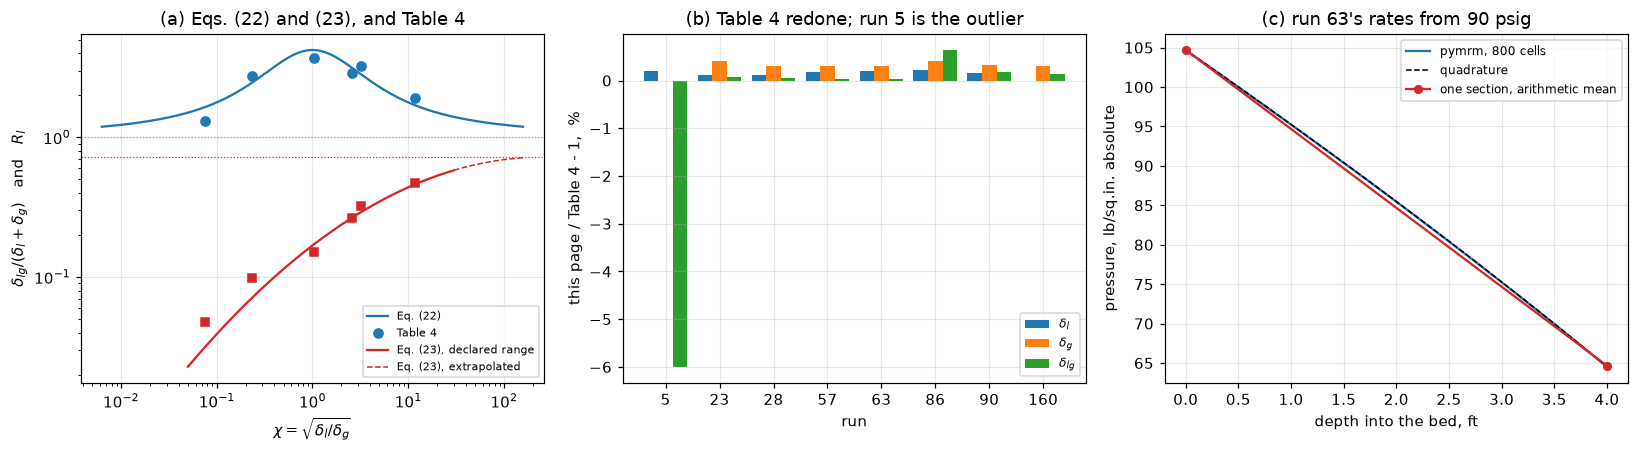

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) the two correlations, with Table 4's points on them
cg = np.logspace(-2.2, 2.2, 500)
ax[0].plot(cg, f22(Cfg(), cg), "C0-", label="Eq. (22)")
fin = np.isfinite(T4.chi.values) & (T4.chi.values > 0)
ax[0].plot(T4.chi.values[fin], T4.two_phase_parameter.values[fin], "C0o",
           ms=6, label="Table 4")
ax[0].axhline(1.0, color="0.6", lw=0.8, ls=":")
cin = np.logspace(np.log10(KV["eq23_chi_min"]), np.log10(KV["eq23_chi_max"]), 300)
ax[0].plot(cin, f23(Cfg(), cin), "C3-", label="Eq. (23), declared range")
cout = np.logspace(np.log10(KV["eq23_chi_max"]), 2.2, 100)
ax[0].plot(cout, f23(Cfg(), cout), "C3--", lw=1,
           label="Eq. (23), extrapolated")
ax[0].plot(T4.chi.values[fin], T3.liquid_saturation_pct.values[fin] / 100, "C3s",
           ms=5)
ax[0].axhline(S["eq23_ceiling_liquid_saturation"], color="C3", lw=0.8, ls=":")
ax[0].set_xscale("log"), ax[0].set_yscale("log")
ax[0].set_xlabel(r"$\chi=\sqrt{\delta_l/\delta_g}$")
ax[0].set_ylabel(r"$\delta_{lg}/(\delta_l+\delta_g)$   and   $R_l$")
ax[0].set_title("(a) Eqs. (22) and (23), and Table 4")
ax[0].legend(fontsize=7)

# (b) the reproduction, run by run
w = 0.27
x = np.arange(len(T3))
ax[1].bar(x - w, np.where(R["_dl"] > 0,
                          (R["_dl"] / T4.delta_l_psi_per_ft.replace(0, np.nan) - 1) * 100,
                          0), w, label=r"$\delta_l$")
ax[1].bar(x, np.where(R["_dg"] > 0,
                      (R["_dg"] / T4.delta_g_psi_per_ft.replace(0, np.nan) - 1) * 100,
                      0), w, label=r"$\delta_g$")
ax[1].bar(x + w, R["_e_dlg_all"], w, label=r"$\delta_{lg}$")
ax[1].set_xticks(x), ax[1].set_xticklabels(T3.run)
ax[1].set_xlabel("run"), ax[1].set_ylabel("this page / Table 4 - 1,  %")
ax[1].set_title("(b) Table 4 redone; run 5 is the outlier")
ax[1].legend(fontsize=8)

# (c) the column
xg, _, _, Pc = fv_solve(Cfg(), col, PIN, L4, 800)
ax[2].plot(xg, Pc, "C0-", label="pymrm, 800 cells")
Ls = np.linspace(0.05, L4, 40)
ax[2].plot(Ls, [quad_outlet(col, PIN, L) for L in Ls], "k--", lw=1,
           label="quadrature")
ax[2].plot([0, L4], [PIN, recipe_outlet(col, PIN, L4, 1)], "C3o-", ms=5,
           label="one section, arithmetic mean")
ax[2].set_xlabel("depth into the bed, ft")
ax[2].set_ylabel("pressure, lb/sq.in. absolute")
ax[2].set_title("(c) run 63's rates from 90 psig")
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Validation

### What is being validated, ranked

1. **The worked example.** Table 3 to Table 4 is the authors' own arithmetic,
   printed in full. Reproducing it tests the transcription, the equations, the
   constants, the unit conversions and the manometer correction all at once,
   against numbers nobody on this page chose. This is the top of the builder
   brief's ranking and it is where the page's weight sits.
2. **Two asymptotic checks the paper states for its own data.** The
   single-phase limits: run 160 is gas alone, where $\chi \to 0$, and run 5 is
   liquid alone, where $\chi \to \infty$, and the paper says the two-phase
   parameter approaches unity at both ends. **These are asymptotic statements
   about the Figure 7 cloud, not per-row requirements**, and section 3 above
   weighs both rows against the scatter the same paper prints for that cloud
   rather than treating one as a requirement.
3. **A stated numerical result in the text**: the average-pressure claim of
   book p. 236, checked algebraically for one phase and numerically for two.
4. **Nothing from a figure.** No curve is traced; the correlation curves plotted
   above are the printed equations.

**And what is NOT validation.** The comparison of Eqs. (22)/(23) with Table 4 is
a goodness of fit to data inside the fit. It is on the page because the size of
the residuals is informative, and it is printed beside two nulls so that it
cannot be read as more.

### The break table

Every row below perturbs one transcribed constant, one modelling choice or one
numerical setting and **re-enters the same block functions** that produced the
reported numbers. The coverage map underneath is generated from the measured
moves; it is never a hand-written claim. An AST guard parses each row's own
source and rejects any metric returned as a typed constant, and the cell after
it states what that guard cannot do.


In [15]:
BREAKS, BREAK_FNS = [], []
MOVE_TOL = 1e-6
BLOCKS = {"repro": block_repro, "recon": block_recon, "run5": block_run5,
          "corr": block_corr, "shape": block_shape, "col": block_col,
          "spread": block_spread}


def ALL(cfg, which=("repro", "recon", "run5", "corr", "shape", "col",
                    "spread")):
    """Recompute the named blocks under a perturbed Cfg.

    Per-block fault tolerance is deliberate: a perturbation severe enough to
    make the COLUMN solve diverge must not silently cost the reproduction and
    correlation metrics their coverage.  Any block that raises is recorded
    under its own key and reported.
    """
    out = {}
    for k in which:
        try:
            out.update({a: b for a, b in BLOCKS[k](cfg).items()
                        if not a.startswith("_")})
        except Exception as exc:                   # noqa: BLE001
            out[f"_raised_{k}"] = f"{type(exc).__name__}: {exc}"
    return out


def brk(label, fn, note=""):
    try:
        got = fn()
    except Exception as exc:                       # noqa: BLE001
        got = {"_raised": f"{type(exc).__name__}: {exc}"}
    BREAKS.append((label, got, note))
    BREAK_FNS.append((label, fn))


def _alpha_150():
    return ALL(replace(Cfg(), alpha=KV["cylinder_alpha"]), ("repro", "run5", "col"))


brk("alpha transcribed as Ergun's own 150 where the paper prints 266", _alpha_150,
    "book p. 236 prints THREE (alpha, beta) pairs in one sentence and only one"
    " belongs to the Raschig rings Tables 3 and 4 are for; this is the mistake"
    " of taking the first pair the sentence names")


def _beta_175():
    return ALL(replace(Cfg(), beta=KV["cylinder_beta"]), ("repro", "run5", "col"))


brk("beta transcribed as 1.75 where the paper prints 2.33", _beta_175,
    "the turbulent term carries almost all of delta at these Reynolds numbers,"
    " so this is the single most damaging constant on the page")


def _s_low():
    return ALL(replace(Cfg(), s_surf=147.5))


brk("specific surface at 147.5, the bottom of what '148' rounds from", _s_low,
    "NOT A DEFECT ROW.  S is printed to three figures and N_Re = 6G/(S mu)"
    " depends on nothing else, so this prices the printed precision itself, and"
    " it is how the page establishes that the 0.15 % systematic in the Reynolds"
    " column is inside the paper's own rounding rather than a transcription"
    " error")


def _s_high():
    return ALL(replace(Cfg(), s_surf=148.5))


brk("specific surface at 148.5, the top of the same interval", _s_high,
    "the other edge.  The implied-specific-surface metric barely moves under"
    " either, and that INVARIANCE is the reason it is reported: the offset"
    " recovers the same S whatever S is assumed")


def _no_manometer():
    return ALL(replace(Cfg(), manometer=False), ("repro", "run5", "col"))


brk("the manometer correction of book p. 236 left out", _no_manometer,
    "one sentence, one foot of water, and without it the delta_lg column is"
    " wrong by tens of percent - including run 160, where the correction still"
    " applies although no liquid is flowing")


def _rho_liquid():
    return ALL(replace(Cfg(), rho_m_mode="liquid"), ("repro", "run5", "col"))


brk("rho_m taken as the liquid density instead of Eq. (21)'s mixture", _rho_liquid,
    "Eq. (21) is why the liquid saturation has to be MEASURED before delta_lg"
    " can be computed at all; this row is what ignoring it costs")


def _mu_table2():
    return ALL(replace(Cfg(), mu_air_mode="table2"), ("repro", "run5", "col"))


brk("air viscosity fixed at Table 2's 0.0192 cP instead of the recovered line",
    _mu_table2,
    "prices the reconstruction where it is used.  delta_g barely notices,"
    " because the turbulent Ergun term is viscosity-free (N_Re^2 mu^2 has no"
    " mu), which is also why the recovery had to be done on the Reynolds column"
    " and not on delta")


def _dp_nominal():
    return ALL(replace(Cfg(), dp_override=0.375 / 12.0))


DP_NOMINAL_OVER_EFFECTIVE_PCT = 100.0 * (0.375 / 12.0 / Cfg().dp - 1.0)

brk("D_p taken as the nominal 3/8 in. instead of Eq. (19)'s 6(1-eps)/S",
    _dp_nominal,
    f"Raschig rings are not spheres; Eq. (19) is what the specific surface is"
    f" printed for, and the nominal size is"
    f" {DP_NOMINAL_OVER_EFFECTIVE_PCT:.1f} % larger than the effective diameter"
    f" it gives ({0.375:.3f} in against {Cfg().dp*12:.4f} in).  COMPUTED, not"
    f" typed, and pinned in CLAIMS below")


def _gc_exact():
    return ALL(replace(Cfg(), gc=32.174049), ("repro", "run5", "col"))


brk("g_c taken at the exact 32.174 instead of the printed 32.17", _gc_exact,
    "the two-unit-system check uses cfg.gc on BOTH sides, so this row moves the"
    " reproduction and the recovered 3600 while leaving that identity exactly"
    " where it was - which is what a structural metric looks like from outside")


def _p_atm_147():
    return ALL(replace(Cfg(), p_atm=14.7), ("repro", "run5", "col"))


brk("standard atmosphere taken as 14.7 instead of 14.696", _p_atm_147,
    "Table 3's pressures are gauge, so this constant is unavoidable and it is"
    " not the paper's; the row shows how little of the answer rides on it")


def _t_ref_80():
    return ALL(replace(Cfg(), t_air_ref=80.0), ("repro", "run5", "col"))


brk("Table 2's air density read as 0.0808 at 80 F instead of at 32 F", _t_ref_80,
    "Table 2 prints one temperature in parentheses per cell and they differ"
    " within a single row: air is 0.0808 (32) for density and 0.0192 (80) for"
    " viscosity")


def _cp_rounded():
    return ALL(replace(Cfg(), cp=6.72e-4 * 60.0))


brk("1 centipoise rounded to 6.72e-4 lb/(ft.sec)", _cp_rounded,
    "the textbook rounding.  It moves the Reynolds columns in the fourth"
    " decimal, an order below the systematic the printed S already explains."
    "  IT IS ALSO THE ROW THAT CAUGHT A BUG IN THIS PAGE: the ft-lb-second"
    " route used to read the conversion from the module rather than from Cfg,"
    " so this row perturbed one side of the two-unit-system check and not the"
    " other and lifted that machine-noise identity above ABS_FLOOR - a break row"
    " that did not reach the code it claims to perturb, and a 'structural' metric"
    " excused on a reason that was false for the one row making the excuse"
    " necessary.  The guard added for it is measured, with a negative control,"
    " in the coverage cell below")


def _eps_sphere():
    return ALL(replace(Cfg(), eps=KV["sphere_bed_porosity"]))


brk("porosity taken as the 3/8-in. SPHERE value 0.362", _eps_sphere,
    "book p. 233 prints four porosities for four packings and this is the wrong"
    " one.  It leaves N_Re untouched - 6/S carries no porosity - and wrecks"
    " delta, which is the clearest demonstration on the page that the two"
    " columns test different things")


def _eq22_ln():
    return ALL(replace(Cfg(), eq22_ln=True), ("corr", "shape", "col"))


brk("Eq. (22) read with natural logs instead of log_10", _eq22_ln,
    "the printed subscript 10 is about 1.5 mm high on a 300 ppi scan and the"
    " equation is well formed either way")


def _eq22_swap():
    return ALL(replace(Cfg(), eq22_a=KV["eq22_offset"], eq22_b=KV["eq22_numerator"]),
               ("corr", "shape", "col"))


brk("Eq. (22)'s two constants swapped: 0.666/((log chi)^2 + 0.416)", _eq22_swap,
    "both numbers sit in the same printed fraction and neither is"
    " dimensionally distinguishable from the other")


def _eq23_sign():
    return ALL(replace(Cfg(), eq23_c=(KV["eq23_c0"], KV["eq23_c1"], -KV["eq23_c2"])),
               ("corr", "shape", "col"))


brk("Eq. (23)'s quadratic term transcribed as +0.109", _eq23_sign,
    "the sign is what makes Eq. (23) a fit with a ceiling instead of a runaway,"
    " and that ceiling is one of the page's reported numbers")


def _eq23_transpose():
    return ALL(replace(Cfg(), eq23_c=(KV["eq23_c0"], 0.252, KV["eq23_c2"])),
               ("corr", "shape", "col"))


brk("Eq. (23)'s linear coefficient read as 0.252, a transposition of 0.525",
    _eq23_transpose,
    "the row that moves Eq. (23)'s SHAPE while leaving it a well-formed"
    " downward parabola: where the ceiling sits, how high it is, and what the"
    " equation returns at each end of its declared range")


def _eq23_fig7_reading():
    return ALL(replace(Cfg(), eq23_c=(KV["eq23_c0_figure7"], KV["eq23_c1"],
                                      KV["eq23_c2"])),
               ("corr", "shape", "col"))


brk("Eq. (23) taken with the constant term Figure 7 prints, -0.744",
    _eq23_fig7_reading,
    "NOT AN INVENTED PERTURBATION.  The paper prints the saturation fit TWICE"
    " with two different constant terms - -0.774 as Eq. (23) on book p. 237 and"
    " -0.744 inside Figure 7 on the same page - and this row is the second"
    " reading run through everything the first one feeds.  It is what makes the"
    " defect a measurement rather than an observation")


def _chi_inv():
    return ALL(replace(Cfg(), chi_inverted=True), ("corr", "shape", "col"))


brk("chi defined as sqrt(delta_g/delta_l), the reciprocal of the printed one",
    _chi_inv,
    "the notation on book p. 239 and the annotation inside Figs. 5 and 7 both"
    " print delta_l over delta_g.  Eq. (22) is EVEN in log chi, so this row is"
    " invisible to the friction correlation and only the saturation metrics"
    " catch it - which is precisely why they are not decoration")


def _no_gravity():
    return ALL(replace(Cfg(), gravity=False), ("col",))


brk("the gravity term of Eq. (5) dropped from the column", _no_gravity,
    "delta is (-dP/dL) + rho, and that plus sign is why a two-phase bed can"
    " lose less pressure than its friction loss; without it the single-phase"
    " downflow check collapses onto the horizontal one")


def _no_two_phase():
    return ALL(replace(Cfg(), two_phase=False), ("col",))


brk("the two-phase correlation switched off: delta_lg = delta_l + delta_g",
    _no_two_phase,
    "THE NULL MODEL run as a break row rather than described.  With no"
    " interaction the loss is again a constant plus something proportional to"
    " 1/P, and the average-pressure claim comes most of the way back - which is"
    " the page's evidence that it is Eqs. (22) and (23) that break it")


def _inlet_rule():
    return ALL(replace(Cfg(), mean_rule="inlet"), ("col",))


brk("the section evaluated at its INLET pressure, not the mean of its terminals",
    _inlet_rule,
    "the row that shows what the printed claim is FOR: an endpoint rule is"
    " first order in the section length where the arithmetic mean is second,"
    " and it destroys the single-phase identity outright")


def _geom_rule():
    return ALL(replace(Cfg(), mean_rule="geometric"), ("col",))


brk("the geometric mean of the terminals instead of the arithmetic one",
    _geom_rule,
    "the nearest plausible alternative, and the one that shows the claim is"
    " about THIS mean: the same two terminal pressures, eight orders of"
    " difference on the single-phase identity")


def _sampled():
    return ALL(replace(Cfg(), rootfind=False), ("shape", "col"))


brk("extrema and thresholds SAMPLED on a grid instead of root-found", _sampled,
    "the defect the builder brief names outright.  Eq. (23)'s maximum lands on"
    " a grid point and the 1 % bed length lands on a 0.1 ft grid")


def _loose_root():
    return ALL(replace(Cfg(), root_xtol=1e-4), ("shape",))


brk("the root-finder's tolerance loosened to 1e-4", _loose_root,
    "separates the root-finder's own error from the physics: it is the row that"
    " moves the closed-form check on Eq. (23)'s maximum, and the reason that"
    " check is reported as a solver check and not as agreement")


def _coarse_fv():
    return ALL(replace(Cfg(), n_fv=(50, 100)), ("col",))


brk("the column solved on 50 and 100 cells instead of 800 and 1600", _coarse_fv,
    "prices the finite-volume grid against the 0.33 % effect it is used to"
    " measure")


def _no_extrap():
    return ALL(replace(Cfg(), fv_extrapolate=False), ("col",))


brk("the Richardson extrapolation switched off", _no_extrap,
    f"first-order upwind at {max(Cfg().n_fv)} cells is still"
    f" {COL['fv_rel_error_at_n_fine']:.1e} wrong -"
    f" {EXTRAP_ORDERS_BELOW_NFINE:.1f} orders worse than the extrapolated pair,"
    f" and uncomfortably close to the recipe error at short beds")


def _demo_run_mild():
    """The demonstration column built on the MILDEST two-phase row instead of
    the most severe one."""
    return ALL(replace(Cfg(), demo_run=int(min(
        SPR["_lens"], key=lambda r: -SPR["_lens"][r]))), ("col",))


brk(f"the demonstration column built on the mildest two-phase row of Table 3"
    f" instead of run {Cfg().demo_run}, the most severe", _demo_run_mild,
    f"THE ROW THAT MOVES THE EVALUATION POINT, and the reason it exists: the"
    f" 1 % bed length is reported at ONE run, and without this row no"
    f" perturbation on the page could touch that choice.  It moves the headline"
    f" from {SPR['two_phase_recipe_1pct_length_min_ft']:.4f} ft to"
    f" {SPR['two_phase_recipe_1pct_length_max_ft']:.4f} ft - a factor of"
    f" {SPR['two_phase_recipe_1pct_length_max_ft']/SPR['two_phase_recipe_1pct_length_min_ft']:.0f}"
    f" - which is the spread the printed table above shows, and is why the"
    f" headline is labelled a worst case")


def _cbv_read():
    return ALL(replace(Cfg(), outlet_read="cbv"), ("col",))


brk("the outlet read through compute_boundary_values instead of the last cell",
    _cbv_read,
    "not a defect row either: it swaps which of two first-order reads is"
    " reported and inverts the ratio between them.  It is here so that the"
    " choice made in the implementation is a measured one rather than a habit")

for label, got, note in BREAKS:
    print(f"* {label}")
    shown = {k: v for k, v in got.items() if not k.startswith("_")}
    raised = {k: v for k, v in got.items() if k.startswith("_raised")}
    print(f"    {len(shown)} metrics recomputed"
          + (f"   BLOCKS THAT RAISED: {raised}" if raised else ""))
    if note:
        print(f"    -> {note}")

* alpha transcribed as Ergun's own 150 where the paper prints 266
    29 metrics recomputed
    -> book p. 236 prints THREE (alpha, beta) pairs in one sentence and only one belongs to the Raschig rings Tables 3 and 4 are for; this is the mistake of taking the first pair the sentence names
* beta transcribed as 1.75 where the paper prints 2.33
    29 metrics recomputed
    -> the turbulent term carries almost all of delta at these Reynolds numbers, so this is the single most damaging constant on the page
* specific surface at 147.5, the bottom of what '148' rounds from
    68 metrics recomputed
    -> NOT A DEFECT ROW.  S is printed to three figures and N_Re = 6G/(S mu) depends on nothing else, so this prices the printed precision itself, and it is how the page establishes that the 0.15 % systematic in the Reynolds column is inside the paper's own rounding rather than a transcription error
* specific surface at 148.5, the top of the same interval
    68 metrics recomputed
    -> the oth

In [16]:
METRICS = {}
for _blk in (R, REC, F5, C, S, COL, SPR):
    METRICS.update({k: float(v) for k, v in _blk.items() if not k.startswith("_")})

# ---- coverage: GENERATED from the break rows' measured moves ---------------
# BOTH DIRECTIONS ARE ASSERTED.  Metric -> row is the usual one.  Row -> metric
# is the hole it leaves: coverage alone never checks that each ROW moves
# something, so a row whose perturbation had been neutered - replace(Cfg()) with
# no field changed - would run clean and print "N metrics recomputed" while
# proving nothing.  ROW_MOVES closes that, and is printed per row below.
COVERAGE, UNKNOWN, ROW_MOVES = {}, [], {}
for _label, _got, _note in BREAKS:
    if not isinstance(_got, dict):
        continue
    ROW_MOVES.setdefault(_label, 0)
    for _k, _v in _got.items():
        if _k.startswith("_"):
            continue
        if _k not in METRICS:
            UNKNOWN.append((_label, _k))
            continue
        _b = METRICS[_k]
        _rel = abs(float(_v) - _b) / max(abs(_b), abs(float(_v)), 1e-300)
        if _rel > MOVE_TOL:
            COVERAGE.setdefault(_k, []).append((_label, _rel))
            ROW_MOVES[_label] += 1
assert not UNKNOWN, f"break rows recompute names that are not metrics: {UNKNOWN}"
DEAD_ROWS = sorted(k for k, v in ROW_MOVES.items() if v == 0)
assert not DEAD_ROWS, (
    f"break rows that move NOTHING - a neutered perturbation looks exactly like"
    f" this and coverage alone cannot see it: {DEAD_ROWS}")

# ---- and the rows must COMPUTE what they return ---------------------------
# A row returning a typed constant records a move of exactly 1.0 whatever the
# reported value is, so its coverage links cannot fail: a hand-written coverage
# claim wearing the generator's clothes.  This guard parses each row's own
# source plus one level of the helpers it names, and rejects any agreement.json
# key bound to a numeric literal or to a local name only ever assigned one.
import ast
import inspect
import textwrap


def _is_number(node):
    if isinstance(node, ast.Constant):
        return isinstance(node.value, (int, float)) and not isinstance(node.value, bool)
    return (isinstance(node, ast.UnaryOp) and isinstance(node.op, (ast.UAdd, ast.USub))
            and _is_number(node.operand))


def _key_bindings(src):
    tree, out = ast.parse(textwrap.dedent(src)), []
    for n in ast.walk(tree):
        if isinstance(n, ast.Dict):
            out += [(k.value, v) for k, v in zip(n.keys, n.values)
                    if isinstance(k, ast.Constant) and isinstance(k.value, str)]
        elif isinstance(n, ast.DictComp):
            for gen in n.generators:
                out += [(c.value, n.value) for c in ast.walk(gen.iter)
                        if isinstance(c, ast.Constant) and isinstance(c.value, str)]
        elif isinstance(n, ast.Call) and getattr(n.func, "id", "") == "dict":
            out += [(kw.arg, kw.value) for kw in n.keywords if kw.arg]
        elif isinstance(n, ast.Assign):
            for t in n.targets:
                if (isinstance(t, ast.Subscript) and isinstance(t.slice, ast.Constant)
                        and isinstance(t.slice.value, str)):
                    out.append((t.slice.value, n.value))
    return out


def _sources(fn):
    try:
        src = textwrap.dedent(inspect.getsource(fn))
    except (OSError, TypeError):
        return ["# UNREADABLE SOURCE"]
    seen = [src]
    for n in ast.walk(ast.parse(src)):
        if isinstance(n, ast.Name):
            obj = globals().get(n.id)
            if inspect.isfunction(obj) and obj is not fn:
                try:
                    seen.append(textwrap.dedent(inspect.getsource(obj)))
                except (OSError, TypeError):
                    seen.append(f"# UNREADABLE SOURCE: {n.id}")
    return seen


def literal_metrics(fn):
    bad = []
    for src in _sources(fn):
        try:
            tree = ast.parse(src)
        except SyntaxError:
            continue
        frozen = {t.id for n in ast.walk(tree) if isinstance(n, ast.Assign)
                  for t in n.targets if isinstance(t, ast.Name) and _is_number(n.value)}
        bad += [k for k, v in _key_bindings(src) if k in METRICS
                and (_is_number(v) or (isinstance(v, ast.Name) and v.id in frozen))]
    return sorted(set(bad))


def _negative_control():
    """THE GUARD'S TEETH: a row that types its metrics instead of computing them."""
    _frozen = 5.60
    out = {"eq23_ceiling_liquid_saturation": 0.7214,
           "two_phase_recipe_1pct_length_ft": _frozen,
           **{k: 3600.0 for k in ("gc_minute_conversion_recovered",)}}
    out["choking_length_ft"] = 8.06
    return out


CAUGHT = literal_metrics(_negative_control)
LITERAL_ROWS = {lbl: bad for lbl, fn in BREAK_FNS for bad in [literal_metrics(fn)] if bad}
assert set(CAUGHT) == {"eq23_ceiling_liquid_saturation",
                       "two_phase_recipe_1pct_length_ft",
                       "gc_minute_conversion_recovered",
                       "choking_length_ft"}, (
    f"the literal guard no longer catches the row it was written for: {CAUGHT}")
assert not LITERAL_ROWS, f"break rows returning typed constants: {LITERAL_ROWS}"
print(f"{len(BREAK_FNS)} break rows parsed; {len(LITERAL_ROWS)} return a metric as a"
      f" typed constant.\nNegative control caught all four forms it uses:"
      f" {CAUGHT}")
print("WHAT THE GUARD CANNOT DO, so that it is not over-trusted: it rejects a"
      " numeric LITERAL, and a"
      "\nlocal name only ever bound to one, walking one level into the helpers"
      " a row names.  It sees"
      "\nliterals in a dict display, in dict(...), in an out[k] = ..."
      " assignment, through a {**d} merge,"
      "\nand in a dict comprehension over literal key strings.  What still"
      " passes: float(0.72), 0.72*1.0,"
      "\nnp.float64(0.72), a comprehension over a NAME, and a literal returned"
      " two call levels down."
      "\nAnd it can NEVER tell whether a computed expression is the RIGHT one -"
      " only the measured moves"
      f"\nbelow can, and only for the metrics they move.  All {len(BREAK_FNS)}"
      " rows here perturb one Cfg field"
      "\nand re-enter the same block functions that produced the reported"
      " numbers.")

# ---- structural metrics, named rather than left to be discovered -----------
STRUCTURAL = {
    "delta_l_two_unit_systems_max_rel_diff":
        "Eq. (17) in minute units against the primitive Ergun expression in"
        " ft-lb-second units.  Both routes take alpha, beta, D_p, eps, g_c AND"
        " the centipoise conversion from the same Cfg - the last of those was"
        " read from the module until the guard below caught it - so it is an"
        " ALGEBRA check and every constant cancels: it cannot detect a wrong"
        " alpha, a wrong D_p, a wrong g_c or a wrong centipoise."
        "  delta_l_max_rel_error_pct detects all four.",
    "eq22_argmax_chi":
        "(log_10 chi)^2 is EVEN, so Eq. (22) peaks at chi = 1 for any values of"
        " the two printed constants.  No perturbation of them moves this, and"
        " it cannot detect a wrong 0.416 or 0.666 - eq22_max_parameter does.",
    "eq22_null_unity_rms_log_dev":
        "a statistic of the printed Table 4 column alone.  Nothing transcribed"
        " on this page enters it, which is exactly what makes it a null"
        " baseline; eq22_gain_over_bestconst is the movable comparison.",
    "eq22_null_bestconst_rms_log_dev":
        "likewise a statistic of the printed column alone.",
    "eq22_free_rows_null_bestconst_rms_log_dev":
        "the same null restricted to the six rows where Eq. (22) is free -"
        " still a statistic of the printed Table 4 column alone, so nothing"
        " transcribed here moves it, and it cannot detect anything about"
        " Eq. (22).  eq22_free_rows_gain_over_bestconst is the movable"
        " comparison it exists to be a baseline for.",
    "eq23_null_bestconst_rms_dev_pct":
        "a statistic of the printed liquid-saturation column over the rows"
        " inside 0.05 < chi < 30.  It moves only if that row SET changes, and"
        " the one row that could change it - chi read upside down - happens to"
        " select the same six runs, because inverting chi maps this sample onto"
        " itself inside the range.  That is measured, not assumed: the break"
        " row is present and its move is below the tolerance.  It cannot detect"
        " anything about Eq. (23); eq23_rms_dev_pct is the comparison it exists"
        " to be a baseline for.",
    "mu_air_linear_fit_max_resid_pct":
        "the residual of the recovered air viscosity against a straight line is"
        " SCALE-INVARIANT: S, D_p, the porosity and the centipoise conversion"
        " each multiply all seven recovered values by one factor and leave the"
        " relative residual identical, and the porosity does not even enter"
        " (6/S carries none).  So nothing on this page moves it, and it cannot"
        " detect any of those four - mu_air_at_80F_vs_table2_pct detects all"
        " four.  What it CAN say, and what it is for, is whether the recovery"
        " has structure or is noise.",
    "mu_air_at_80F_offset_corrected_vs_table2_pct":
        "invariant for the same reason and by construction: the offset is"
        " measured on the liquid rows under the same common factor, so"
        " dividing by it cancels exactly.  That invariance is the reason the"
        " out-of-sample check is quoted in this form - it is a statement about"
        " the paper's air viscosity and not about this page's geometry -"
        " and the uncorrected mu_air_at_80F_vs_table2_pct is the movable"
        " companion.",
    "fv_observed_order":
        "first-order upwind on a uniform grid converges at 1 whatever the"
        " source term is, so this cannot detect a wrong dP/dz, a wrong boundary"
        " condition or a wrong outlet read.  fv_rel_error_at_n_fine and"
        " fv_extrapolated_vs_quadrature_rel detect all three.",
}
FLOOR = 1e-12
BELOW_FLOOR = sorted(k for k, v in METRICS.items() if abs(v) < FLOOR)
CI_TOL = 0.05          # check_agreement.py's REL_TOL: a smaller move is invisible
BEST = {k: max(r for _, r in v) for k, v in COVERAGE.items()}
UNCOVERED = sorted(set(METRICS) - set(COVERAGE))
WEAK = sorted(k for k, r in BEST.items() if r < CI_TOL and k not in STRUCTURAL)

print(f"\n{'metric':52s}{'rows':>6}{'best move':>12}")
for k in sorted(METRICS):
    n = len(COVERAGE.get(k, []))
    tag = "   STRUCTURAL" if k in STRUCTURAL else ("   < CI 5 %" if k in WEAK else "")
    print(f"{k:52s}{n:6d}{BEST.get(k, 0.0):12.3e}{tag}")
print(f"\n{len(METRICS)} metrics; {len(COVERAGE)} moved by at least one break row;"
      f" {len(UNCOVERED)} not moved.")
print(f"{sum(len(v) for v in COVERAGE.values())} measured row-metric links from"
      f" {len(BREAKS)} rows.")
print(f"\nAND THE OTHER DIRECTION, WHICH COVERAGE ALONE CANNOT SEE: metrics"
      f" MOVED by each row.")
print(f"A row whose perturbation had been neutered would still print"
      f" \"N metrics recomputed\"; it would")
print(f"print 0 here, and the assertion above would fire.")
for _lbl, _n in sorted(ROW_MOVES.items(), key=lambda kv: (kv[1], kv[0])):
    print(f"  {_n:3d}  {_lbl}")
print(f"weakest row moves {min(ROW_MOVES.values())} metric(s); strongest"
      f" {max(ROW_MOVES.values())}; all {len(ROW_MOVES)} rows move at least one.")
print(f"\nSTRUCTURAL, and what each one CANNOT detect:")
for k, why in STRUCTURAL.items():
    print(f"  {k}\n      {why}")
print(f"\nbelow check_agreement.py's ABS_FLOOR = {FLOOR:g}, so outside the"
      f" regression suite while BOTH sides stay there: {BELOW_FLOOR}")
print("  their above-floor companions, from the same computations and INSIDE"
      " the suite:")
print("    delta_l_two_unit_systems_max_rel_diff -> delta_l_max_rel_error_pct,"
      " gc_minute_conversion_recovered")
print("    gas_horizontal_arith_mean_max_rel_error ->"
      " gas_horizontal_geom_mean_max_rel_error,")
print("                                             "
      " gas_downflow_arith_mean_rel_error_2ft,"
      " two_phase_recipe_rel_error_4ft")
assert set(UNCOVERED) <= set(STRUCTURAL), (
    f"metrics with no measured move and no structural label: "
    f"{sorted(set(UNCOVERED) - set(STRUCTURAL))}")
assert not WEAK, f"non-structural metrics whose best cover is below CI's 5 %: {WEAK}"
# AND THE LABELS THEMSELVES ARE ENFORCED, not merely counted: a metric called
# structural must in fact have no row that moves it past what CI can see.  One
# metric is exempt from that on the ground that it sits below ABS_FLOOR, where a
# "relative move" is the ratio of two machine-noise values.
MISLABELLED = sorted(k for k in STRUCTURAL
                     if k not in BELOW_FLOOR and BEST.get(k, 0.0) >= CI_TOL)
assert not MISLABELLED, (
    f"metrics labelled STRUCTURAL that a break row moves past CI's"
    f" {CI_TOL:.0%}: {MISLABELLED}")
assert set(STRUCTURAL) <= set(METRICS), (
    f"structural labels naming things that are not metrics:"
    f" {sorted(set(STRUCTURAL) - set(METRICS))}")

# ---- AND THE EXEMPTION IS MEASURED, NOT ASSERTED ---------------------------
# The excuse above is only honest if EVERY row leaves the metric under the
# floor: the moment one lifts it above ABS_FLOOR, check_agreement.py's
# comparison engages (it skips only while BOTH sides are under) and the move
# stops being noise over noise.  This guard exists because it FIRED.  The
# ft-lb-second route used to read the centipoise conversion from the module
# instead of from Cfg, so the rounded-centipoise row perturbed one side of the
# two-unit-system identity and not the other, lifting it far above the floor -
# and the exemption's stated reason was false for the one row that made the
# exemption necessary.  The negative control below is that old code path,
# evaluated live rather than remembered.
EXCUSED = sorted(set(STRUCTURAL) & set(BELOW_FLOOR))
FLOOR_MOVES = {k: sorted(float(_g[k]) for _l, _g, _ in BREAKS
                         if isinstance(_g, dict) and k in _g)
               for k in BELOW_FLOOR}
LIFTED = sorted(k for k in EXCUSED if any(abs(v) >= FLOOR for v in FLOOR_MOVES[k]))
assert not LIFTED, (
    f"metrics excused as below-floor that a break row lifts above ABS_FLOOR"
    f" {FLOOR:g}, where check_agreement.py does compare them: {LIFTED}")

_mlq = T3.liquid_rate_lb_sqft_min.values > 0
_cfg_r = replace(Cfg(), cp=6.72e-4 * 60.0)          # the _cp_rounded row
_L, _mul = (T3.liquid_rate_lb_sqft_min.values[_mlq],
            T3.liquid_viscosity_cP.values[_mlq])
_dl_r = delta_eq17(_cfg_r, reynolds(_cfg_r, _L, _mul), _mul, _cfg_r.rho_w)
_dl_module = delta_ergun_primitive(replace(_cfg_r, cp=CP_LB_FT_MIN), _L, _mul,
                                   _cfg_r.rho_w)
FLOOR_GUARD_NEGATIVE_CONTROL = float(np.max(np.abs(_dl_module / _dl_r - 1.0)))
assert FLOOR_GUARD_NEGATIVE_CONTROL >= FLOOR, (
    "the negative control no longer reproduces the defect this guard was"
    f" written for: {FLOOR_GUARD_NEGATIVE_CONTROL:.3e}")
print(f"\nTHE BELOW-FLOOR EXEMPTION, MEASURED.  {len(EXCUSED)} of the"
      f" {len(STRUCTURAL)} structural labels is excused from the enforcement"
      f" above")
print(f"because it sits under ABS_FLOOR: {EXCUSED}.  That excuse is only honest"
      f" if EVERY break row")
print(f"leaves it there, so that is what is asserted - and the other below-floor"
      f" metric shows the")
print(f"difference between an exemption and a coverage:")
for _k, _vs in sorted(FLOOR_MOVES.items()):
    print(f"  {_k}")
    print(f"     {len(_vs)} recomputations, {min(_vs):.3e} to {max(_vs):.3e},"
          f" best 'move' {BEST.get(_k, 0.0):.3e}")
    print(f"     -> " + ("EXCUSED, and asserted to stay under the floor: every"
                         " move there is noise over noise"
                         if _k in EXCUSED else
                         "NOT excused - break rows lift it above the floor and"
                         " into CI's comparison, which"
                         "\n        is what makes it covered rather than"
                         " exempt"))
print(f"THE ASSERTION IS THE POINT, NOT THE SENTENCE.  Negative")
print(f"control, run live: reading the centipoise conversion from the module"
      f" instead of from Cfg makes")
print(f"the rounded-centipoise row lift the two-unit-system identity to"
      f" {FLOOR_GUARD_NEGATIVE_CONTROL:.3e} - above the floor,")
print(f"inside CI's comparison, and with the row still not reaching the code it"
      f" claims to perturb.")
print(f"That was this page's own bug, and it is why the guard is here rather"
      f" than a comment.")
print(f"\nweakest non-structural cover:"
      f" {min(((v, k) for k, v in BEST.items() if k not in STRUCTURAL))[::-1]}")

report_agreement("G1.1", METRICS)

29 break rows parsed; 0 return a metric as a typed constant.
Negative control caught all four forms it uses: ['choking_length_ft', 'eq23_ceiling_liquid_saturation', 'gc_minute_conversion_recovered', 'two_phase_recipe_1pct_length_ft']
WHAT THE GUARD CANNOT DO, so that it is not over-trusted: it rejects a numeric LITERAL, and a
local name only ever bound to one, walking one level into the helpers a row names.  It sees
literals in a dict display, in dict(...), in an out[k] = ... assignment, through a {**d} merge,
and in a dict comprehension over literal key strings.  What still passes: float(0.72), 0.72*1.0,
np.float64(0.72), a comprehension over a NAME, and a literal returned two call levels down.
And it can NEVER tell whether a computed expression is the RIGHT one - only the measured moves
below can, and only for the metrics they move.  All 29 rows here perturb one Cfg field
and re-enter the same block functions that produced the reported numbers.

metric                                

{'page': 'G1.1',
 'metrics': {'re_liquid_max_rel_error_pct': 0.1740599258342801,
  're_liquid_rms_rel_error_pct': 0.14652134164539382,
  're_air_table2_viscosity_max_rel_error_pct': 2.211577949415,
  'delta_l_max_rel_error_pct': 0.2176850280899867,
  'delta_l_rms_rel_error_pct': 0.17568177089341294,
  'delta_g_max_rel_error_pct': 0.4161486975375661,
  'delta_lg_max_rel_error_pct': 0.6389899227959184,
  'delta_lg_rms_rel_error_pct': 0.26001485931669954,
  'delta_l_two_unit_systems_max_rel_diff': 5.551115123125783e-16,
  'gc_minute_conversion_recovered': 3593.8277230313556,
  'reynolds_systematic_offset_pct': 0.1453841322700576,
  'reynolds_offset_spread_pct': 0.05153861610405208,
  'reynolds_offset_implied_specific_surface': 148.21516851575967,
  'mu_air_linear_fit_max_resid_pct': 0.0258613655242379,
  'mu_air_slope_cP_per_degF': 2.7649447314362385e-05,
  'mu_air_at_80F_vs_table2_pct': 0.8185823440481688,
  'mu_air_at_80F_offset_corrected_vs_table2_pct': 0.6722209092422604,
  'run5_delt

### Every number written on this page, checked against the computation

The cell below pins every number that appears in the markdown of this notebook,
in `meta.yaml`, in `README.md`, in the CSV sidecars and in
`../models_entry.yaml` against the live computation, and **the notebook fails to
execute if any of them drifts**. Under it is a mechanical sweep of the same
files, and - because a sweep trusted past its reach is worse than none - a count
of what that sweep cannot see.


In [17]:
CLAIMS = [
    # ---- the worked example
    ("liquid Reynolds, worst %", 0.174, R["re_liquid_max_rel_error_pct"], 5e-4),
    ("liquid Reynolds, r.m.s. %", 0.147, R["re_liquid_rms_rel_error_pct"], 5e-4),
    ("air Reynolds on Table 2's viscosity, worst %", 2.212,
     R["re_air_table2_viscosity_max_rel_error_pct"], 5e-4),
    ("delta_l, worst %", 0.218, R["delta_l_max_rel_error_pct"], 5e-4),
    ("delta_l, r.m.s. %", 0.176, R["delta_l_rms_rel_error_pct"], 5e-4),
    ("delta_g, worst %", 0.416, R["delta_g_max_rel_error_pct"], 5e-4),
    ("delta_lg, worst %", 0.639, R["delta_lg_max_rel_error_pct"], 5e-4),
    ("delta_lg, r.m.s. %", 0.260, R["delta_lg_rms_rel_error_pct"], 5e-4),
    ("the two unit systems agree to", 5.6e-16,
     R["delta_l_two_unit_systems_max_rel_diff"], 5e-17),
    ("g_c minute factor recovered", 3593.8,
     R["gc_minute_conversion_recovered"], 0.05),
    ("against an exact 60 squared", 3600.0, 60.0**2, 0.0),
    # ---- the systematic, and the reconstruction
    ("Reynolds systematic offset %", 0.1454,
     REC["reynolds_systematic_offset_pct"], 5e-5),
    ("its spread, points", 0.0515, REC["reynolds_offset_spread_pct"], 5e-5),
    ("implied specific surface", 148.22,
     REC["reynolds_offset_implied_specific_surface"], 5e-3),
    ("the mass-rate range it holds across, fold", 27.887,
     MASS_RATE_RANGE_FOLD, 5e-4),
    ("air viscosity line, worst residual %", 0.0259,
     REC["mu_air_linear_fit_max_resid_pct"], 5e-5),
    ("that line at 80 F vs Table 2, %", 0.819,
     REC["mu_air_at_80F_vs_table2_pct"], 5e-4),
    ("the same, offset-corrected, %", 0.672,
     REC["mu_air_at_80F_offset_corrected_vs_table2_pct"], 5e-4),
    # ---- run 5
    ("run 5 delta_lg error %", -5.99, F5["run5_delta_lg_rel_error_pct"], 5e-3),
    ("dP/dL Table 4 implies for run 5", 2.469,
     F5["run5_dpdl_implied_by_table4_psi_per_ft"], 5e-4),
    ("run 5 parameter from Table 3", 0.9408,
     F5["run5_two_phase_parameter_from_table3"], 5e-5),
    ("run 160 delta_lg error %", 0.134,
     F5["run160_delta_lg_rel_error_pct"], 5e-4),
    ("run 5 parameter off unity, %", -5.92,
     F5["run5_parameter_gap_from_unity_pct"], 5e-3),
    ("what the manometer correction is worth on run 160, %", 22.29,
     F5["run160_manometer_correction_worth_pct"], 5e-3),
    ("run 160 measured vs Ergun, %", 0.93, R160_ERGUN, 5e-3),
    ("run 5 measured vs Ergun, %", 0.081, R5_ERGUN, 5e-4),
    ("how much closer run 5 sits", 11.5, R160_ERGUN / R5_ERGUN, 5e-2),
    # ---- the correlations, and their nulls
    ("Eq. (22) worst %", 25.53, C["eq22_max_abs_dev_pct"], 5e-3),
    ("Eq. (22) r.m.s. %", 12.81, C["eq22_rms_dev_pct"], 5e-3),
    ("Eq. (22) r.m.s. log", 0.0531, C["eq22_rms_log_dev"], 5e-5),
    ("null: no interaction", 0.3666, C["eq22_null_unity_rms_log_dev"], 5e-5),
    ("null: best constant", 0.2151, C["eq22_null_bestconst_rms_log_dev"], 5e-5),
    ("gain over that constant", 4.05, C["eq22_gain_over_bestconst"], 5e-3),
    # ---- and the same, on the six rows where Eq. (22) is free
    ("Eq. (22) r.m.s. on the six free rows, %", 14.79,
     C["eq22_free_rows_rms_dev_pct"], 5e-3),
    ("its r.m.s. log there", 0.0613, C["eq22_free_rows_rms_log_dev"], 5e-5),
    ("the null there", 0.1520,
     C["eq22_free_rows_null_bestconst_rms_log_dev"], 5e-5),
    ("the gain there", 2.48, C["eq22_free_rows_gain_over_bestconst"], 5e-3),
    ("how much the eight-row gain flatters, %", 63.0,
     100 * (C["eq22_gain_over_bestconst"]
            / C["eq22_free_rows_gain_over_bestconst"] - 1), 5e-1),
    ("rows where Eq. (22) is pinned by a limit", 2.0,
     float(np.sum(~C["_free"])), 0.0),
    ("Eq. (23) worst %", 33.90, C["eq23_max_abs_dev_pct"], 5e-3),
    ("Eq. (23) r.m.s. %", 19.55, C["eq23_rms_dev_pct"], 5e-3),
    ("Eq. (23) null, r.m.s. %", 117.9,
     C["eq23_null_bestconst_rms_dev_pct"], 5e-2),
    ("its gain over that constant", 6.03,
     C["eq23_null_bestconst_rms_dev_pct"] / C["eq23_rms_dev_pct"], 5e-3),
    ("rows outside 20 %", 2.0, C["eq23_rows_outside_20pct"], 0.0),
    # ---- the same equation as Figure 7 prints it
    ("Eq. (23), Figure 7 constant, worst %", 29.17,
     C["eq23_fig7_max_abs_dev_pct"], 5e-3),
    ("the same, r.m.s. %", 18.33, C["eq23_fig7_rms_dev_pct"], 5e-3),
    ("its rows outside 20 %", 3.0, C["eq23_fig7_rows_outside_20pct"], 0.0),
    ("r.m.s. points the text reading gives away", 1.2232,
     C["eq23_text_minus_fig7_rms_dev_pct"], 5e-5),
    ("what the constant is worth in R_l, %", 7.15,
     100 * (10**(KV["eq23_c0_figure7"] - KV["eq23_c0"]) - 1), 5e-3),
    ("Figure 7 reading's ceiling", 0.7730,
     S["eq23_fig7_ceiling_liquid_saturation"], 5e-5),
    ("its discriminant", -0.0488, S["eq23_fig7_discriminant"], 5e-5),
    ("rows inside Eq. (23)'s range", 6.0, float(C["_inr"].sum()), 0.0),
    # ---- the shapes, root-found
    ("Eq. (22) maximum", 4.2133, S["eq22_max_parameter"], 5e-5),
    ("at chi", 1.0, S["eq22_argmax_chi"], 5e-9),
    ("Eq. (23) maximum at chi", 256.010, S["eq23_argmax_chi"], 5e-4),
    ("root-found to", 1.2e-09, S["eq23_argmax_root_vs_analytic_rel"], 5e-10),
    ("Eq. (23) ceiling", 0.7214, S["eq23_ceiling_liquid_saturation"], 5e-5),
    ("Eq. (23) at chi = 30, %", 58.03,
     100 * S["eq23_at_chi_upper_limit"], 5e-3),
    ("Eq. (23) at chi = 0.05, %", 2.283,
     100 * S["eq23_at_chi_lower_limit"], 5e-4),
    ("discriminant", -0.0618,
     S["eq23_discriminant_at_saturation_unity"], 5e-5),
    # ---- the column
    ("the claim, one phase, horizontal", 1.16e-13,
     COL["gas_horizontal_arith_mean_max_rel_error"], 5e-15),
    ("the geometric mean instead", 1.12e-05,
     COL["gas_horizontal_geom_mean_max_rel_error"], 5e-8),
    ("with gravity, 2 ft", 1.72e-07,
     COL["gas_downflow_arith_mean_rel_error_2ft"], 5e-10),
    ("one section over 4 ft, %", 0.332,
     100 * COL["two_phase_recipe_rel_error_4ft"], 5e-4),
    ("bed length at 1 %, ft", 5.6012,
     COL["two_phase_recipe_1pct_length_ft"], 5e-5),
    ("the same on the mildest two-phase row, ft", 466.9537,
     SPR["two_phase_recipe_1pct_length_max_ft"], 5e-4),
    ("the same on the most severe, ft", 5.6012,
     SPR["two_phase_recipe_1pct_length_min_ft"], 5e-5),
    ("two-phase runs inside the 7 ft column", 1.0,
     SPR["two_phase_recipe_1pct_runs_inside_experimental_column"], 0.0),
    ("two-phase runs inside the 40 ft reactor", 4.0,
     SPR["two_phase_recipe_1pct_runs_inside_commercial_reactor"], 0.0),
    ("two-phase runs in Table 3", 6.0, float(len(SPR["_lens"])), 0.0),
    ("air friction loss over its static head at the inlet", 129.0,
     COL["gas_friction_over_static_head_at_inlet"], 5e-2),
    ("choking length, ft", 8.0627, COL["choking_length_ft"], 5e-5),
    ("sectioning order", 1.9999, COL["sectioning_observed_order"], 5e-5),
    ("finite-volume order", 1.0001, COL["fv_observed_order"], 5e-5),
    ("extrapolated pymrm vs quadrature", 7.5e-10,
     COL["fv_extrapolated_vs_quadrature_rel"], 5e-11),
    ("the same on the compute_boundary_values read", 1.1e-09,
     CBV_EXTRAP_VS_QUAD, 5e-11),
    ("cbv over the upwind face read", 3.84,
     COL["cbv_over_upwind_face_outlet_error_ratio"], 5e-3),
    ("orders between the extrapolated pair and the recipe error", 6.6,
     EXTRAP_ORDERS_BELOW_RECIPE, 5e-2),
    ("orders between the extrapolated pair and 1600 cells", 4.1,
     EXTRAP_ORDERS_BELOW_NFINE, 5e-2),
    # ---- what the outlet face actually transports
    ("outlet-face row of conv, last weight", 1.125, OUTLET_ROW[-1], 5e-12),
    ("outlet-face row of conv, the one before", -0.125, OUTLET_ROW[-2], 5e-12),
    ("that flux against compute_boundary_values", 0.0,
     OUTLET_FLUX_VS_CBV, 1e-12),
    ("a true v*P_N march over the cbv error", 1.0002, MARCH_OVER_CBV, 5e-4),
    ("nominal 3/8 in. over Eq. (19)'s D_p, %", 60.59,
     DP_NOMINAL_OVER_EFFECTIVE_PCT, 5e-3),
    # ---- counts quoted in the metadata
    ("metrics", 68.0, float(len(METRICS)), 0.0),
    ("break rows", 29.0, float(len(BREAKS)), 0.0),
    ("metrics moved by a row", 61.0, float(len(COVERAGE)), 0.0),
    ("structural metrics", 9.0, float(len(STRUCTURAL)), 0.0),
    ("of those, enforced directly against CI", 8.0,
     float(len(STRUCTURAL) - len(EXCUSED)), 0.0),
    ("and excused as below the ABS_FLOOR", 1.0, float(len(EXCUSED)), 0.0),
    ("metrics below ABS_FLOOR", 2.0, float(len(BELOW_FLOOR)), 0.0),
    ("Table 3 rows", 8.0, float(len(T3)), 0.0),
]
BAD = [(n, w, g) for n, w, g, t in CLAIMS if not abs(w - g) <= t]
for n, w, g, t in CLAIMS:
    print(f"  {'ok ' if abs(w - g) <= t else 'DRIFT'} {n:44s} written {w:>12}"
          f"   computed {g:.10g}")
assert not BAD, f"prose has drifted from the computation: {BAD}"
print(f"\nall {len(CLAIMS)} numbers written in prose match the live computation")


  ok  liquid Reynolds, worst %                     written        0.174   computed 0.1740599258
  ok  liquid Reynolds, r.m.s. %                    written        0.147   computed 0.1465213416
  ok  air Reynolds on Table 2's viscosity, worst % written        2.212   computed 2.211577949
  ok  delta_l, worst %                             written        0.218   computed 0.2176850281
  ok  delta_l, r.m.s. %                            written        0.176   computed 0.1756817709
  ok  delta_g, worst %                             written        0.416   computed 0.4161486975
  ok  delta_lg, worst %                            written        0.639   computed 0.6389899228
  ok  delta_lg, r.m.s. %                           written         0.26   computed 0.2600148593
  ok  the two unit systems agree to                written      5.6e-16   computed 5.551115123e-16
  ok  g_c minute factor recovered                  written       3593.8   computed 3593.827723
  ok  against an exact 60 squared      

In [18]:
# --- mechanical sweep of the metadata and this notebook's markdown ----------
import json
import re
from pathlib import Path

LIVE = set()
for _v in METRICS.values():
    for _s in (1.0, 100.0, 0.01, 1e-4):
        LIVE.add(abs(float(_v)) * _s)
for _n, _w, _g, _t in CLAIMS:
    LIVE.add(abs(float(_g)))
for _df in (T3, T4):
    for _v in np.asarray(_df.select_dtypes("number").to_numpy(), float).ravel():
        if np.isfinite(_v):
            LIVE.add(abs(_v))
LIVE.update(abs(float(v)) for v in KV.values())
LIVE.update({P_ATM, R_OFF, CP_LB_FT_MIN / 60.0, CP_LB_FT_MIN, SEC_PER_MIN2,
             Cfg().dp, 32.174049, 0.375 / 12.0, 6.72e-4, 6.71968975,
             10.1002})   # the DOI registrant prefix, which the regex sees
LIVE.update(mv for rows in COVERAGE.values() for _, mv in rows)
LIVE = {x for x in LIVE if np.isfinite(x)}

LIVE_INT = {len(T3), len(T4), len(K), len(METRICS), len(BREAKS), len(COVERAGE),
            len(UNCOVERED), len(BELOW_FLOOR), len(CLAIMS), len(STRUCTURAL),
            int(round(100 * CI_TOL)), sum(len(v) for v in COVERAGE.values()),
            int(C["eq23_rows_outside_20pct"]), int(C["_inr"].sum()),
            int(round(SEC_PER_MIN2)), 60, int(round(COL["_Pin"])), 144}
LIVE_INT.update(int(round(v)) for v in KV.values() if abs(v - round(v)) < 1e-9)
LIVE_INT.update((50, 100, 200, 400, 800, 1600, 3200))
# LIVE, NOT EXEMPT: the ratios the prose rounds to an integer.  Each is computed
# above and pinned in CLAIMS; they are here so the integer sweep can see them
# without putting a computable number into the source-integer escape hatch, which
# is exactly the hole an earlier hand-entered "93" sat in - and, one round later,
# the hole a hand-entered "28" sat in, where it passed only because 28 is also a
# Table 3 run number and so lands in TABLE_INTS.  A computable number in that
# hatch is checked by coincidence or not at all.
LIVE_INT.add(int(round(COL["gas_friction_over_static_head_at_inlet"])))
LIVE_INT.add(int(round(SPR["two_phase_recipe_1pct_length_max_ft"])))
LIVE_INT.add(int(round(SPR["two_phase_recipe_1pct_length_max_ft"]
                       / SPR["two_phase_recipe_1pct_length_min_ft"])))
LIVE_INT.add(int(round(DP_NOMINAL_OVER_EFFECTIVE_PCT)))
LIVE_INT.add(int(round(MASS_RATE_RANGE_FOLD)))
TABLE_INTS = set()
for _df in (T3, T4):
    for _v in np.asarray(_df.select_dtypes("number").to_numpy(), float).ravel():
        for _s in (_v, 10 * _v, 100 * _v, 1000 * _v, 1e4 * _v):
            if np.isfinite(_s) and abs(_s - round(_s)) < 1e-9 and 0 < _s < 1e8:
                TABLE_INTS.add(int(round(_s)))
SOURCE_INTS = {
    1961, 1959, 1960, 1949, 1952, 1947, 1940, 2026,       # years named on the page
    231, 232, 233, 234, 235, 236, 237, 238, 239,          # book pages
    10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,  # eq. numbers
    32, 43, 45, 48, 89, 39, 537, 861,                     # reference volumes/pages
    690070213, 1002,                                      # the DOI
    300, 230,                                             # ppi; book page offset
    27,         # meta.yaml's declared runtime_seconds and README's "about 27 s".
                 # Genuinely uncheckable from inside: a self-timing would not be
                 # deterministic.  Named here rather than left to be covered by
                 # coincidence - the previous value, 22, passed the sweep only
                 # because 22 is also an equation number.
    600,         # "Over 600 data points are represented", book p. 237
    148, 266,
    2035, 2331, 1181,   # digit runs inside quoted (alpha, beta) strings
    35,          # equipment numerals quoted in the sidecars
    3405, 6200,  # Table 5's Reynolds maxima, quoted in a sidecar
    1800,        # the nbclient timeout in README.md's regenerate snippet
}


THOUSANDS = re.compile(r"(?<=\d)[,]|(?<=\d)\{,\}")


def _read_swept(fn):
    txt = Path(fn).read_text(encoding="utf-8")
    if fn.endswith(".ipynb"):
        txt = "\n".join("".join(c["source"]) for c in json.loads(txt)["cells"]
                        if c["cell_type"] == "markdown")
    # THOUSANDS SEPARATORS ARE STRIPPED BEFORE TOKENISING, in both the plain
    # form "2,739" and the LaTeX form "2{,}739".  The paper prints its Reynolds
    # numbers that way and the prose quotes them that way; without this the
    # integer sweep would see "739" and would have to be told about it by hand,
    # which is the sort of hole a sweep should close rather than open.
    return THOUSANDS.sub("", txt)


TOKEN = re.compile(r"(?<![\w.])(\d+\.\d{4,})(?![\d])")
INT_TOKEN = re.compile(r"(?<![\w.])(\d{2,})(?![\w.])")
FILES = ["meta.yaml", "README.md",
         "data/larkins1961-table3-measured.meta.yaml",
         "data/larkins1961-table4-calculated.meta.yaml",
         "data/larkins1961-printed-constants.meta.yaml",
         "../models_entry.yaml",
         "index.ipynb"]
# SHAPE-DEPENDENT AND BOTH SHAPES PINNED.  integrate_case.py copies page/ only and
# splices models_entry.yaml into models.yaml, so that file is swept HERE, in the
# queue tree, and is ABSENT - and counted as absent - in the published page.
SWEEP_TOKENS_BY_SHAPE = {7: 65, 6: 47}
SWEEP_INTS_BY_SHAPE = {7: 515, 6: 410}


def _half_ulp(tok):
    return 0.5 * 10 ** (-len(tok.split(".")[1]))


def _matches(tok):
    v, h = float(tok), _half_ulp(tok)
    return any(abs(v - c) <= h * (1 + 1e-9) for c in LIVE)


def _int_matches(tok):
    v = int(tok)
    return v in LIVE_INT or v in TABLE_INTS or v in SOURCE_INTS


def _sweep(files):
    tok, unm, corr, rej = [], [], 0, 0
    ints, iunm, irej, ilive, iskip = [], [], 0, 0, 0
    for fn in files:
        if not Path(fn).is_file():
            continue
        text = _read_swept(fn)
        for t in TOKEN.findall(text):
            tok.append((fn, t))
            if not _matches(t):
                unm.append((fn, t))
            corr += 1
            if not _matches(t[:-1] + str((int(t[-1]) + 5) % 10)):
                rej += 1
        for t in INT_TOKEN.findall(text):
            if t.startswith("0"):
                iskip += 1
                continue
            ints.append((fn, t))
            if not _int_matches(t):
                iunm.append((fn, t))
            if int(t) in LIVE_INT or int(t) in TABLE_INTS:
                ilive += 1
            if not _int_matches(t[:-1] + str((int(t[-1]) + 5) % 10)):
                irej += 1
    return tok, unm, corr, rej, ints, iunm, irej, ilive, iskip


PRESENT = [f for f in FILES if Path(f).is_file()]
for _f in FILES:
    if _f not in PRESENT:
        print(f"  (skipped, not present next to the notebook: {_f})")
tokens, unmatched, corrupted, rejected, ints, int_unmatched, int_rejected, \
    int_live, int_skipped = _sweep(PRESENT)
found, found_int, n_files = len(tokens), len(ints), len(PRESENT)
# the OTHER shape, measured here rather than guessed: the published page has no
# ../models_entry.yaml, because integrate_case.py splices it into models.yaml.
OTHER = [f for f in PRESENT if not f.endswith("models_entry.yaml")]
_o = _sweep(OTHER)
found_other, found_int_other = len(_o[0]), len(_o[4])
assert not unmatched, f"prose numbers with no live counterpart: {unmatched}"
assert not int_unmatched, (
    f"integers with no live and no pinned-source counterpart: "
    f"{sorted(set(t for _, t in int_unmatched))} in "
    f"{sorted(set(f for f, _ in int_unmatched))}")
_pin, _pin_int = SWEEP_TOKENS_BY_SHAPE.get(n_files), SWEEP_INTS_BY_SHAPE.get(n_files)
assert _pin in (None, found), (
    f"the sweep found {found} decimal tokens in the {n_files}-file shape, not the"
    f" {_pin} pinned for it")
assert _pin_int in (None, found_int), (
    f"the sweep found {found_int} integer tokens in the {n_files}-file shape, not"
    f" the {_pin_int} pinned for it")
assert SWEEP_TOKENS_BY_SHAPE[len(OTHER)] in (None, found_other), (
    f"the {len(OTHER)}-file shape holds {found_other} decimal tokens, not"
    f" {SWEEP_TOKENS_BY_SHAPE[len(OTHER)]}")
assert SWEEP_INTS_BY_SHAPE[len(OTHER)] in (None, found_int_other), (
    f"the {len(OTHER)}-file shape holds {found_int_other} integer tokens, not"
    f" {SWEEP_INTS_BY_SHAPE[len(OTHER)]}")
print(f"mechanical sweep of {n_files} of the {len(FILES)} files"
      f" (metadata + this notebook's markdown):")
print(f"  {found} numbers written to 4+ decimals, all matching a live value to"
      f" half an ulp.")
print(f"  Teeth: {rejected}/{corrupted} ({rejected/max(corrupted,1):.1%}) of"
      f" last-digit corruptions rejected.")
print(f"  {found_int} integers of 2+ digits ({int_skipped} leading-zero tokens"
      f" skipped): {int_live} match a")
print(f"  count the computation produced or a printed table cell; the other"
      f" {found_int-int_live} sit in the pinned source")
print(f"  set - book pages, equation numbers, years, reference volumes - which"
      f" no computation here can check.")
print(f"  ACHIEVED DETECTION RATE, NOT COMPLETENESS: {int_rejected}/{found_int}"
      f" ({int_rejected/max(found_int,1):.1%}) of last-digit")
print(f"  corruptions of those integers are rejected; the rest land on another"
      f" allowed value.")
print(f"  SHAPE-AWARE, AND BOTH SHAPES ARE PINNED AND MEASURED HERE:"
      f" {SWEEP_TOKENS_BY_SHAPE[7]} decimal and {SWEEP_INTS_BY_SHAPE[7]} integer")
print(f"  tokens across the seven files of the queue tree,"
      f" {SWEEP_TOKENS_BY_SHAPE[6]} and {SWEEP_INTS_BY_SHAPE[6]} across the six of the")
print(f"  published page, where ../models_entry.yaml has been spliced into"
      f" models.yaml and is gone.  The")
print(f"  {n_files}-file shape is the one executing here, and the {len(OTHER)}-file"
      f" count is measured by re-running the")
print(f"  sweep over the same files minus that one rather than predicted.")

WORD_INT = re.compile(r"(?<![\w-])(zero|one|two|three|four|five|six|seven|eight"
                      r"|nine|ten|eleven|twelve|thirteen|fourteen|fifteen"
                      r"|sixteen|seventeen|eighteen|nineteen|twenty)(?![\w-])",
                      re.IGNORECASE)
ONE_DIGIT = re.compile(r"(?<![\w.,])(\d)(?![\w.,])")
n_word = n_one = 0
for fn in PRESENT:
    _t = _read_swept(fn)
    n_word += len(WORD_INT.findall(_t))
    n_one += len(ONE_DIGIT.findall(_t))
print(f"\n  OUTSIDE THE SWEEP ENTIRELY, counted so that it is not mistaken for"
      f" covered: {n_word} word-spelled")
print(f"  small integers and {n_one} single-digit numbers stand in the swept"
      f" prose.  NEITHER CLASS IS CHECKED")
print(f"  against anything.  A count written as a word or as a single digit"
      f" anywhere in these files is")
print(f"  unprotected; the fix is to pin it in CLAIMS above or to write it as a"
      f" numeral of two or more digits,")
print(f"  not to trust this sweep.  Every count quoted in meta.yaml, README.md"
      f" and ../models_entry.yaml is")
print(f"  pinned in CLAIMS for exactly that reason.")


  (skipped, not present next to the notebook: ../models_entry.yaml)
mechanical sweep of 6 of the 7 files (metadata + this notebook's markdown):
  47 numbers written to 4+ decimals, all matching a live value to half an ulp.
  Teeth: 46/47 (97.9%) of last-digit corruptions rejected.
  410 integers of 2+ digits (6 leading-zero tokens skipped): 171 match a
  count the computation produced or a printed table cell; the other 239 sit in the pinned source
  set - book pages, equation numbers, years, reference volumes - which no computation here can check.
  ACHIEVED DETECTION RATE, NOT COMPLETENESS: 135/410 (32.9%) of last-digit
  corruptions of those integers are rejected; the rest land on another allowed value.
  SHAPE-AWARE, AND BOTH SHAPES ARE PINNED AND MEASURED HERE: 65 decimal and 515 integer
  tokens across the seven files of the queue tree, 47 and 410 across the six of the
  published page, where ../models_entry.yaml has been spliced into models.yaml and is gone.  The
  6-file shape i

### Printed features, reported and not repaired

**1. Table 3 and Table 4 disagree about run 5.** Quoted verbatim: Table 3's
run-5 pressure drop is `2.321`, Table 4's run-5 $\delta_{lg}$ is `2.469`, and
for a run with no gas Eq. (20) makes those the same number. Established from
the paper's own arithmetic in the Results section above; **not repaired**, and
this page does not say which cell is wrong.

**2. Eq. (23) is printed twice on book p. 237 with two different constant
terms.** Quoted verbatim, the typeset equation is

> `log_10 R_l = - 0.774 + 0.525 (log_10 chi) - 0.109 (log_10 chi)^2`

and the annotation inside Figure 7, on the facing column of the same page, is

> `log_10 R_l = -0.744 + 0.525 log_10 X - 0.109 (log_10 X)^2`

Every other coefficient agrees, and so does the whole of Eq. (22), which
Figure 7 also prints in full. Both were read on 300 ppi crops enlarged to digit
scale; the difference is a transposition, and it is worth 7.15 % in $R_l$
everywhere. **Where the search went:** Figures 3, 5 and 6 carry the same curves
but print only the labels "EQUATION (22)" and "EQUATION (23)" beside them, not
the coefficients - each was cropped and read - so Figure 7 is the only second
printing of either equation in the paper.

**Neither reading is adopted, and the paper's own printed data cannot settle
it.** The measured comparison is in the Results section: against the six
Table 4 rows inside Eq. (23)'s declared range, Figure 7's constant is better in
r.m.s. and worse on the "within 20 %" count the paper itself uses. Six rows
cannot separate a 7.15 % shift against a standard deviation the paper puts at
16 %. What does *not* depend on resolving it is reported as such: both readings
put the ceiling below a full column and both give a negative discriminant at
$R_l = 1$.

**3. The notation's units make Eq. (17) inconsistent with the printed $g_c$.**
Verbatim: `mu = viscosity, (lb. mass/ft.-min.)` and `g_c = conversion factor,
32.17 pdl./lb.-mass in English units`. With $\mu$ on those units Eq. (17)
reproduces Table 4 only if the conversion factor carries $\mathrm{min}^{-2}$,
i.e. $32.17 \times 3600$; the factor the table actually requires is measured
above and comes back as 3600 to a fraction of a percent. Separately, "pdl./
lb.-mass" is an acceleration - $g_c$ is poundals per pound-**force** - but that
is a reading of the words rather than of the arithmetic, and is recorded as
such. **Neither is repaired**: the page states the reading under which the
paper's own numbers come out, and says it is a reading.

**4. A feature that is NOT filed as a defect.** Eq. (23) cannot return a full
column for any $\chi$, and its maximum sits eight times beyond the upper limit
it is declared for. That is not a defect: the paper says on book p. 238 that
Eq. (23) "is a power series fit which is only good within the limits given",
and it attributes the $R_l \to 1$ and $R_l \to 0$ consistency checks to "the
data of Figure 7" rather than to the equation. The numbers on this page
quantify a caveat the authors print; they do not contradict one.

**Where the search for these went.** All nine pages were rendered at their
native 300 ppi and read; the numerals of Tables 2, 3, 4 and 5, of Eqs. (17),
(18), (19), (20), (21), (22) and (23), and of every equation annotated inside
Figures 3, 5, 6 and 7 were re-read on enlarged crops at digit scale. The claim that no footnote attaches to Table 3 or Table 4 was checked by
cropping the strip beneath each table (Table 3's ends at the two-column text;
Table 4's last row is followed only by the running head). The claim that the
tables are discussed nowhere else was checked by reading both sections that
name them - "DESCRIPTION OF TABULATED PROCESSED DATA" (book p. 234) and
"EXPLANATION OF TABULATED RESULTS" (book p. 236) - in full, plus the
"PRESENTATION OF CORRELATED DATA" section that follows. Reference 4, the
thesis, is not on disk, so nothing here rules out that it addresses run 5.


## What pymrm adds

**Not the correlation, and not the worked example.** Eqs. (17)-(23) are
arithmetic. The reproduction of Table 4 above uses NumPy and nothing else, and
the page says so where it happens rather than dressing algebra as a solve.

**What pymrm buys is the thing the 1961 procedure could only approximate.** The
paper's design calculation is a march with an assumed average pressure per
section, iterated to consistency, and its own step 1 tells the reader to split
the bed when it is long or the loss is large - without saying how long, or how
many sections. Written as a differential equation and solved on a grid, the
same physics answers both questions:

- the one-section recipe is **exact** for a single phase in horizontal flow -
  proved algebraically above and confirmed to 1.16e-13 - so the sectioning advice
  is not about compressibility as such;
- with the two-phase correlation in the loop it reaches 1 % at a bed length
  root-found on the page - inside the paper's own column for the
  largest-friction-loss row of Table 3, and far outside the 40-ft commercial
  reactor for the mildest, which is the spread the page prints rather than
  generalising from the extreme;
- sectioning converges at second order, so the number of sections needed for a
  target accuracy follows from one number instead of from judgement.

The assembly is small: `construct_convflux_upwind` + `construct_div` at
$v = 1$, one pair of outward-normal boundary dictionaries, `NumJac((n, 1))` for
a pointwise source, `newton`. What it is worth is not speed - a quadrature does
this problem too, and is used here as the independent route - but that the same
operators carry over the moment anything else is added to the column: a
reaction, a species balance, a heat balance, or a second spatial dimension.

**An honest limit.** Nothing in this section is validated against a
measurement. The paper reports no axial pressure profile, only a per-foot
gradient from a middle section. What is validated is the *arithmetic*: three
independent routes to the same profile, and an identity that can be proved.


## Reuse

| Change | Where |
|---|---|
| A different packing | `alpha`, `beta`, `eps`, `s_surf` in `Cfg`; book p. 236 prints (118.2, 1.0) for 3/8-in. spheres and (150, 1.75) - Ergun's own - for 1/8-in. cylinders, **neither of which any printed data on this page exercises** |
| A different gas-liquid system | `rho_w`, `rho_air_ref`, `mu_air_*`; Table 2 carries eleven fluids |
| Upflow or horizontal flow | `gravity=False` gives the horizontal case; for upflow change the sign of the $\rho_m$ term in `Column.dPdz`. The paper expects the correlation to hold for both (book p. 238) |
| A reaction in the bed | add a species field: the shape becomes `(n, n_c)` and `NumJac((n, n_c))` couples the last axis in full |
| Heat as well | a second field and a second `construct_div`; the `S3` pattern is unchanged |
| A hold-up closure instead of Eq. (23) | replace `f23`; `G1.7` (Wammes) is the high-pressure alternative and `G1.8` the partial-wetting one |

**Related pages:** `G1.7` Wammes-Westerterp high-pressure trickle-bed
hydrodynamics - the same coupled hold-up/pressure-gradient structure at 7.5 MPa
· `G1.8` trickle-bed partial wetting · `A1.1` Ergun, which is Eq. (17) with
$\alpha = 150$, $\beta = 1.75$ · `F2.3` slurry bubble columns · `F1.4`
Krishna-Ellenberger hold-up.

**Do not reuse the run-5 row as data.** It is on this page as an unresolved
discrepancy, not as a measurement, and the CSV's sidecar says so.

## References

**The source, read.** Larkins, R. P., White, R. R. and Jeffrey, D. W. (1961).
*Two-Phase Concurrent Flow in Packed Beds.* AIChE Journal **7**(2), 231-239.
[doi:10.1002/aic.690070213](https://doi.org/10.1002/aic.690070213). Identity
confirmed on the file's own title page: the title, the by-line "R. P. LARKINS
and R. R. WHITE / University of Michigan, Ann Arbor, Michigan" and "D. W.
JEFFREY / Humble Oil and Refining Company, Baytown, Texas", the abstract, and
the present-address footnote. The DOI is the one the Wiley download stamp
prints in the page margin of the file itself. **PDF page 1 opens with the
NOMENCLATURE and "Manuscript received April 18, 1960" of the PRECEDING
article**, a film-theory/penetration-theory paper; Larkins et al. begin below
the rule on the same page. Book page = PDF page + 230.

**Cited by the paper, not on disk, not read.** Larkins, R. P. (1959). PhD
thesis, University of Michigan, Ann Arbor - the paper's reference 4, "the
complete tabulation of properties, data and results", offered on microfilm.
Reference 4 is also the support the paper gives for the average-pressure claim
this page tests, so what is shown there, and under what assumptions, is
unknown here.

**Named in the paper, not evaluated here.** Ergun, S. (1952), *Chem. Eng.
Progr.* **48**, 89 - reference 3, the origin of Eq. (17)'s form and of the
(150, 1.75) pair. Brownell, L. E. and Katz, D. L. (1947), *Chem. Eng. Progr.*
**43**, 537 - reference 2, whose correlation the paper compares against in
Figure 2 and finds better than Ergun's. Lockhart, R. W. and Martinelli, R. C.
(1949), *Chem. Eng. Progr.* **45**, 39 - reference 6, the open-pipe correlation
whose $X$ this paper's $\chi$ mirrors and whose curves Figure 9 compares
against. Piret, E. L., Mann, C. A. and Wall, T. Jr. (1940), *Ind. Eng. Chem.*
**32**, 861 - reference 9, "the only reference found for two-phase concurrent
flow in packed beds". None of the four is on disk; each is cited, not used.
